<a href="https://colab.research.google.com/github/sl3597/sl3597.github.io/blob/master/a1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install thop ptflops

import time
import warnings
from collections import defaultdict
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import torchvision.models as models
from thop import profile
from ptflops import get_model_complexity_info
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import seaborn as sns
import gc

plt.rcParams["figure.dpi"] = 300
warnings.filterwarnings("ignore")

In [2]:
!nvidia-smi

Wed Feb 25 04:01:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
size = 256 * 1024 * 1024
a = np.random.randn(size // 8).astype(np.float64)
t0 = time.perf_counter()
_ = a.sum()
t1 = time.perf_counter()
bw = a.nbytes / (t1 - t0) / 1e9
print(f"Memory Bandwidth ≈ {bw:.1f} GB/s")

Memory Bandwidth ≈ 10.0 GB/s


# 1. Chip Analysis

------------------------------------------------------------
Chip Name                      | Peak FLOPs    | Bandwidth 
------------------------------------------------------------
AMD EPYC 9654 (Genoa)          | 11400.0       | 460.0     
NVIDIA H100 SXM                | 67000.0       | 3350.0    
NVIDIA A100 PCIe               | 19500.0       | 1935.0    
NVIDIA T4                      | 8100.0        | 320.0     
NVIDIA RTX 5090                | 104800.0      | 1792.0    
NVIDIA RTX 4090                | 82600.0       | 1008.0    
Apple M4 Max                   | 38000.0       | 546.0     
Apple M2 Ultra                 | 31600.0       | 819.2     
Apple M1 Ultra                 | 22000.0       | 819.2     
Google TPU v5p                 | 459000.0      | 2765.0    
Google TPU v4                  | 275000.0      | 1200.0    
Google TPU v3                  | 123000.0      | 900.0     
------------------------------------------------------------


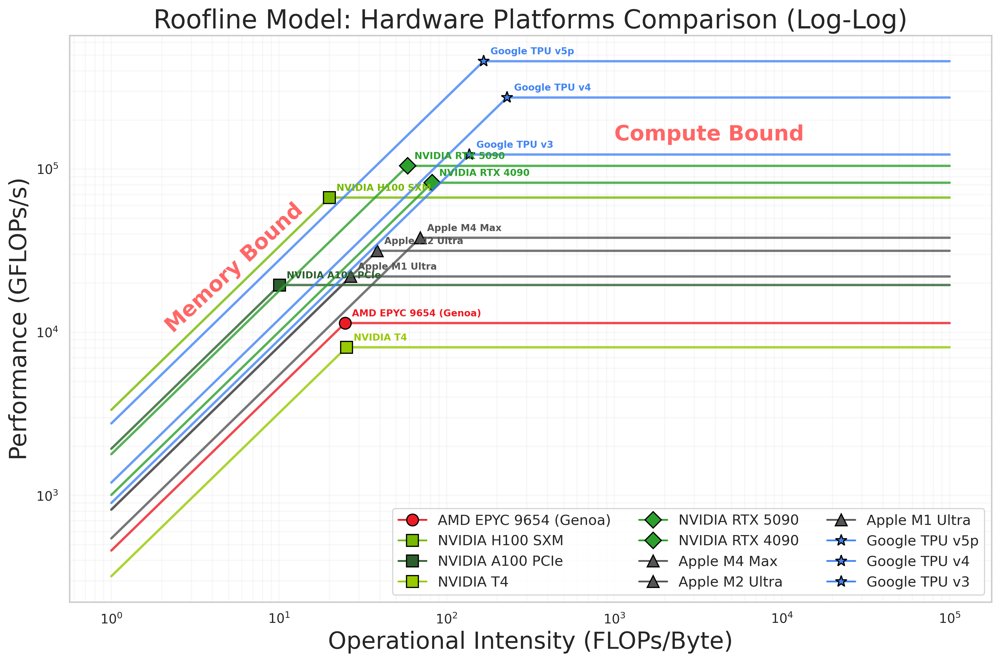

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

hardware_specs = {
    # CPUs (Server)
    "AMD EPYC 9654 (Genoa)": {"peak_flops": 11400, "bandwidth": 460, "type": "CPU", "color": "#ed1c24"},

    # Data Center GPUs
    "NVIDIA H100 SXM": {"peak_flops": 67000, "bandwidth": 3350, "type": "Data Center GPU", "color": "#76b900"},
    "NVIDIA A100 PCIe": {"peak_flops": 19500, "bandwidth": 1935, "type": "Data Center GPU", "color": "#2c5f2d"},
    "NVIDIA T4": {"peak_flops": 8100, "bandwidth": 320, "type": "Data Center GPU", "color": "#97ca00"},

    # Consumer GPUs
    "NVIDIA RTX 5090": {"peak_flops": 104800, "bandwidth": 1792, "type": "Consumer GPU", "color": "#2ca02c"},
    "NVIDIA RTX 4090": {"peak_flops": 82600, "bandwidth": 1008, "type": "Consumer GPU", "color": "#2ca02c"},

    # SoCs (Desktop)
    "Apple M4 Max": {"peak_flops": 38000, "bandwidth": 546, "type": "SoC", "color": "#555555"},
    "Apple M2 Ultra": {"peak_flops": 31600, "bandwidth": 819.2, "type": "SoC", "color": "#555555"},
    "Apple M1 Ultra": {"peak_flops": 22000, "bandwidth": 819.2, "type": "SoC", "color": "#555555"},

    # ASIC
    "Google TPU v5p": {"peak_flops": 459000, "bandwidth": 2765, "type": "ASIC", "color": "#4285F4"},
    "Google TPU v4": {"peak_flops": 275000, "bandwidth": 1200, "type": "ASIC", "color": "#4285F4"},
    "Google TPU v3": {"peak_flops": 123000, "bandwidth": 900, "type": "ASIC", "color": "#4285F4"}
}

def plot_rooflines(specs):
    plt.figure(figsize=(12, 8))

    x = np.logspace(0, 5, 1000)

    markers = {
        "Data Center GPU": "s",
        "Consumer GPU": "D",
        "CPU": "o",
        "SoC": "^",
        "ASIC": "*"
    }

    for name, spec in specs.items():
        peak = spec['peak_flops']
        bw = spec['bandwidth']
        color = spec['color']
        hw_type = spec['type']

        y = np.minimum(peak, bw * x)

        plt.plot(x, y, color=color, linewidth=2, alpha=0.8)

        ridge_x = peak / bw
        ridge_y = peak
        plt.plot(ridge_x, ridge_y, marker=markers.get(hw_type, 'o'),
                 color=color, markersize=10, markeredgecolor='black', label=name)

        plt.text(ridge_x * 1.1, ridge_y * 1.1, name, fontsize=8, color=color, weight='bold')

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Operational Intensity (FLOPs/Byte)', fontsize=20)
    plt.ylabel('Performance (GFLOPs/s)', fontsize=20)
    plt.title('Roofline Model: Hardware Platforms Comparison (Log-Log)', fontsize=22)
    plt.grid(True, which="both", ls="-", alpha=0.15)
    plt.text(2, 10000, "Memory Bound", color='red', fontweight='bold', rotation=43, alpha=0.6, fontsize=18)
    plt.text(1000, 150000, "Compute Bound", color='red', fontweight='bold', alpha=0.6, fontsize=18)
    plt.legend(loc='lower right', bbox_to_anchor=(1, 0), fontsize=12, ncol=3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("-" * 60)
    print(f"{'Chip Name':<30} | {'Peak FLOPs':<13} | {'Bandwidth':<10}")
    print("-" * 60)
    for name, spec in hardware_specs.items():
        print(f"{name:<30} | {spec['peak_flops']:<13.1f} | {spec['bandwidth']:<10.1f}")
    print("-" * 60)

    plot_rooflines(hardware_specs)

# 2. DNN Compute and Memory Analysis

Model                |   GFLOPs | Params (MB) | Acts (MB) | Total (MB) |       OI
---------------------------------------------------------------------------------
MobileNetV2          |    0.655 |       13.37 |    148.50 |     161.87 |     3.86
MobileNetV3_S        |    0.125 |        9.70 |     31.33 |      41.03 |     2.90
ShuffleNetV2         |    0.305 |        8.69 |     41.69 |      50.38 |     5.78
SqueezeNet           |    1.638 |        4.76 |     71.21 |      75.97 |    20.57
MNASNet              |    0.672 |       16.72 |    119.89 |     136.61 |     4.69
VGG11                |   15.218 |      506.83 |    125.37 |     632.21 |    22.96
ResNet18             |    3.648 |       44.59 |     57.05 |     101.64 |    34.23
GoogLeNet            |    3.023 |       25.27 |     60.07 |      85.34 |    33.78
DenseNet121          |    5.794 |       30.44 |    294.20 |     324.64 |    17.02
ResNet50             |    8.267 |       97.49 |    244.45 |     341.94 |    23.06
EfficientNet_B0 

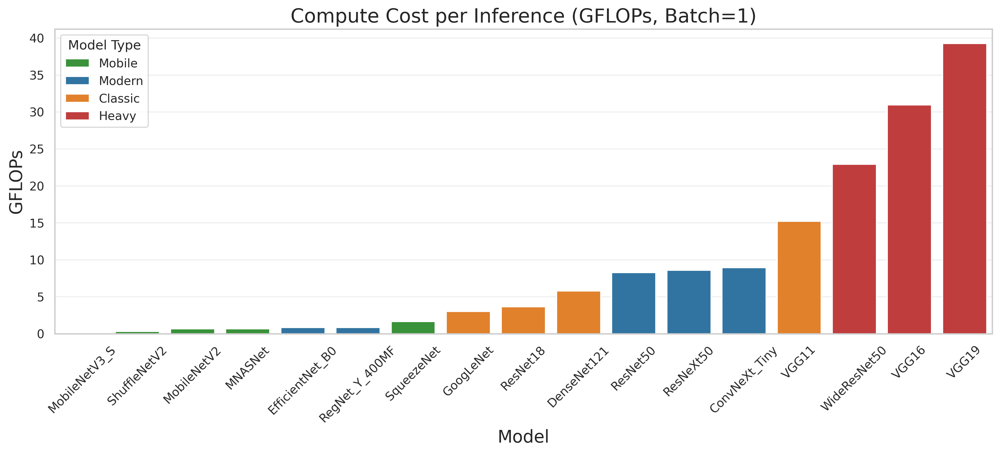

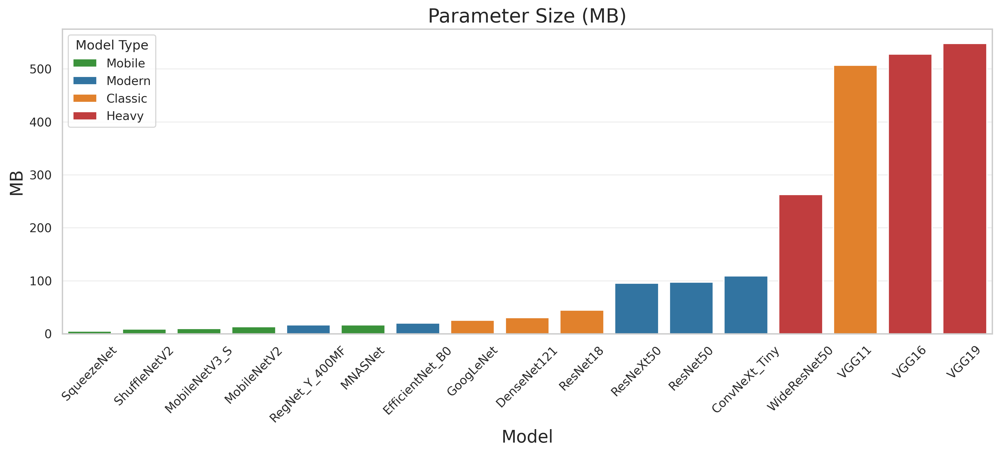

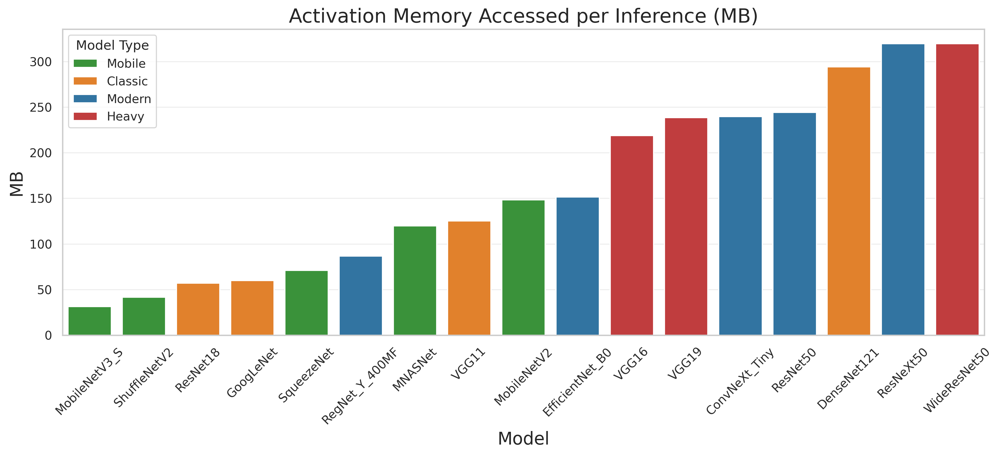

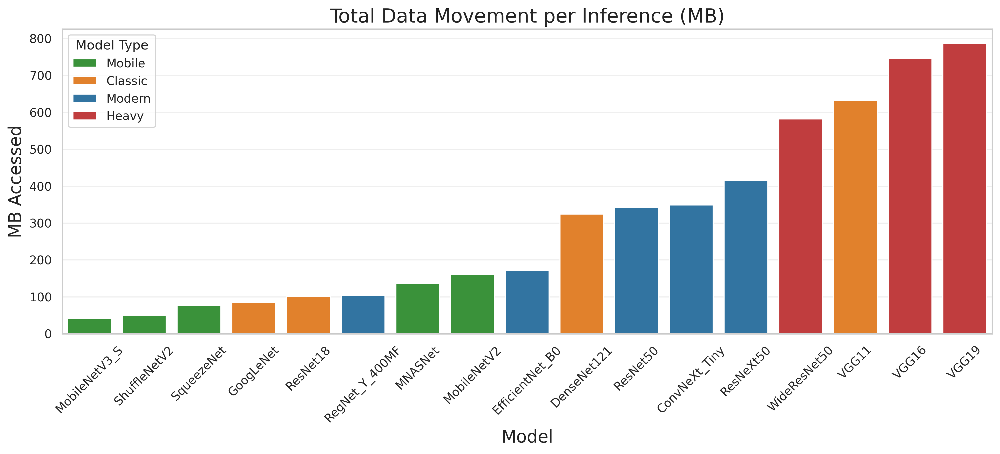

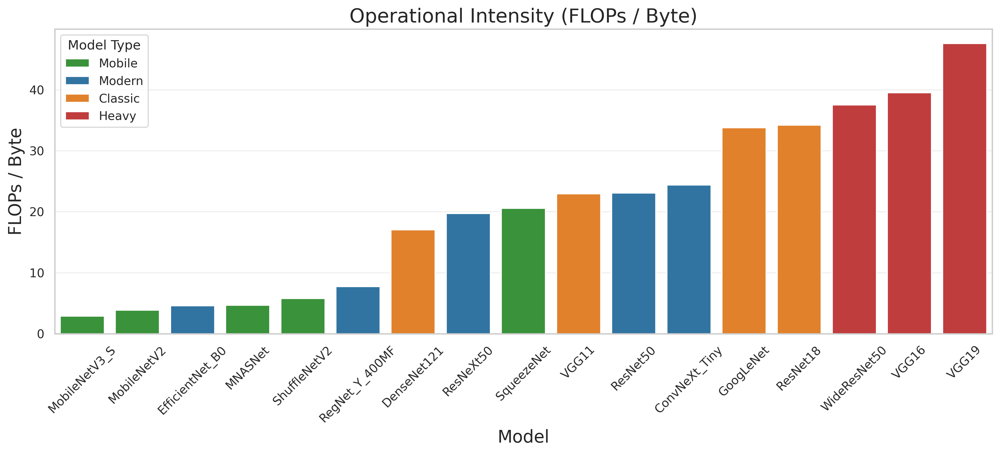

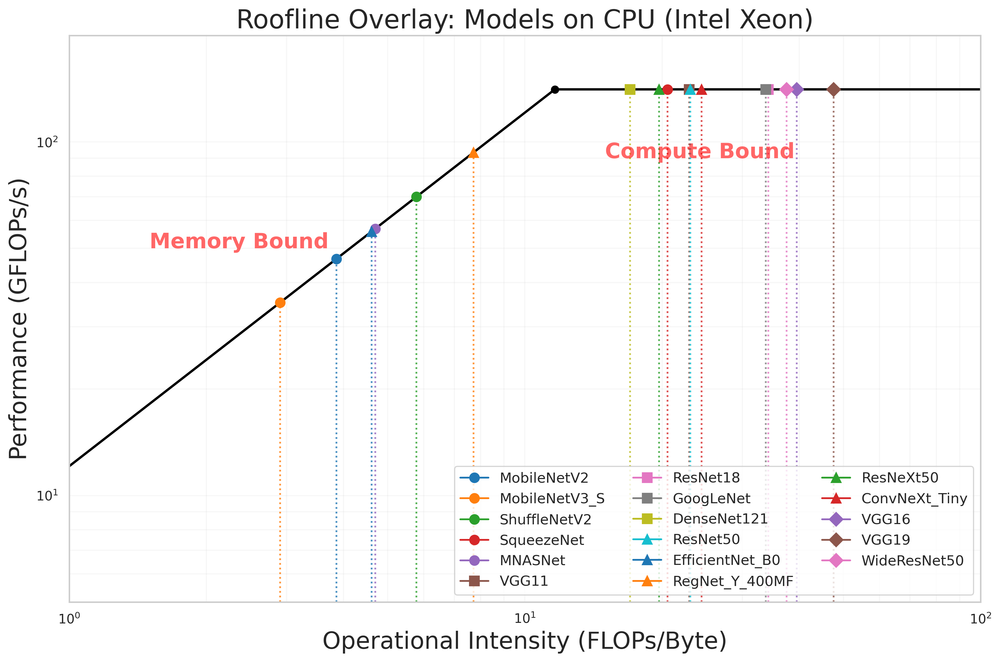

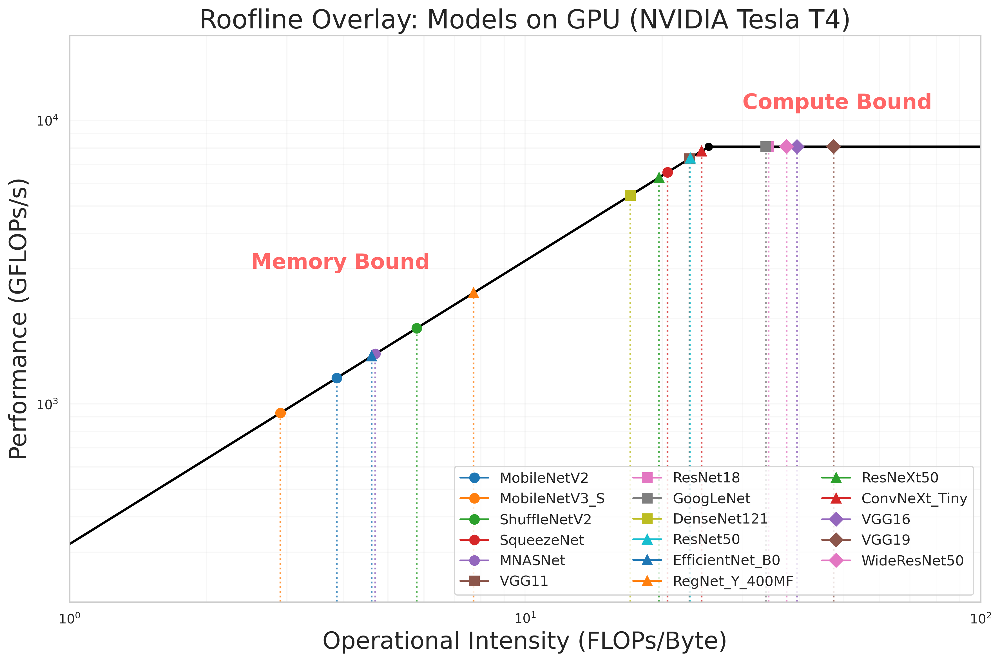

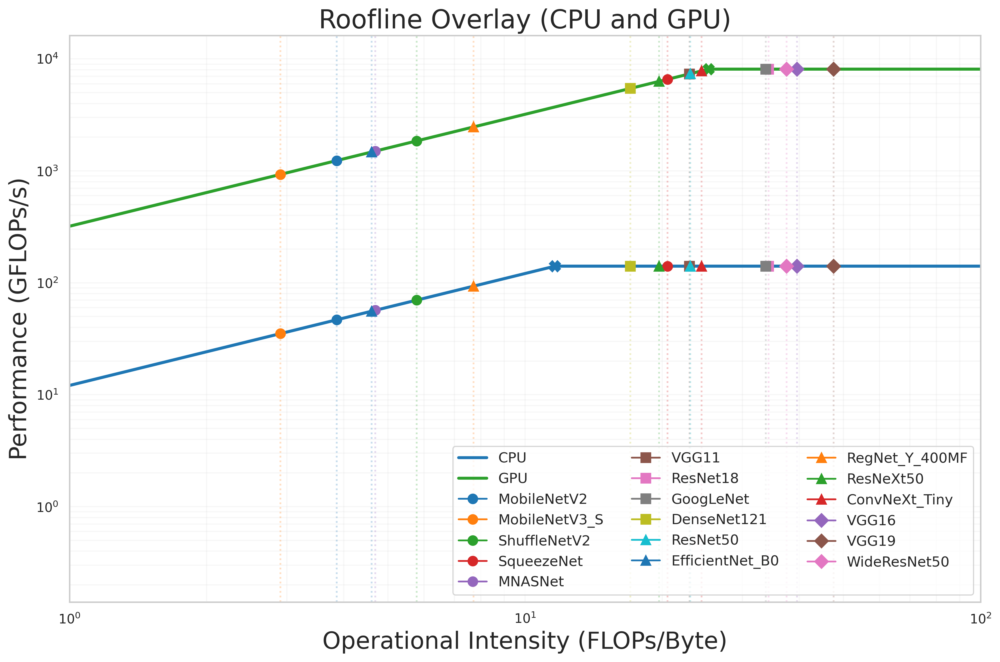


Task 2.4 — Memory/Compute Bound Analysis
Model                |     OI |     CPU (Intel Xeon) | GPU (NVIDIA Tesla T4
---------------------------------------------------------------------------
MobileNetV2          |   3.86 |         Memory Bound |         Memory Bound
MobileNetV3_S        |   2.90 |         Memory Bound |         Memory Bound
ShuffleNetV2         |   5.78 |         Memory Bound |         Memory Bound
SqueezeNet           |  20.57 |        Compute Bound |         Memory Bound
MNASNet              |   4.69 |         Memory Bound |         Memory Bound
VGG11                |  22.96 |        Compute Bound |         Memory Bound
ResNet18             |  34.23 |        Compute Bound |        Compute Bound
GoogLeNet            |  33.78 |        Compute Bound |        Compute Bound
DenseNet121          |  17.02 |        Compute Bound |         Memory Bound
ResNet50             |  23.06 |        Compute Bound |         Memory Bound
EfficientNet_B0      |   4.61 |         Memory

In [5]:
# Hardware specs
colab_specs = {
    "CPU (Intel Xeon)": {
        # Peak FLOPs: 4 cores × 2.2 GHz × 16 FLOPs/cycle (AVX2 FMA, FP32)
        "peak_flops": 140.8,   # GFLOPs/s
        # Bandwidth: empirically measured via numpy read benchmark
        "bandwidth":  12.1,    # GB/s
        "color": "#1f77b4"
    },
    "GPU (NVIDIA Tesla T4)": {
        # Official NVIDIA datasheet: 8.1 TFLOPs FP32
        "peak_flops": 8100,    # GFLOPs/s
        # GDDR6 256-bit @ 10 GT/s = 320 GB/s
        "bandwidth":  320,     # GB/s
        "color": "#2ca02c"
    }
}

colab_specs["CPU"] = colab_specs["CPU (Intel Xeon)"]
colab_specs["GPU"] = colab_specs["GPU (NVIDIA Tesla T4)"]

# Ridge points
for name, spec in colab_specs.items():
    spec["ridge_x"] = spec["peak_flops"] / spec["bandwidth"]

# Task 2.1 — Model definitions
def get_models():
    return {
        # Mobile
        "MobileNetV2": (models.mobilenet_v2(weights=None),          "Mobile"),
        "MobileNetV3_S": (models.mobilenet_v3_small(weights=None),    "Mobile"),
        "ShuffleNetV2": (models.shufflenet_v2_x1_0(weights=None),   "Mobile"),
        "SqueezeNet": (models.squeezenet1_0(weights=None),         "Mobile"),
        "MNASNet": (models.mnasnet1_0(weights=None),            "Mobile"),
        # Classic
        "VGG11": (models.vgg11(weights=None),                 "Classic"),
        "ResNet18": (models.resnet18(weights=None),              "Classic"),
        "GoogLeNet": (models.googlenet(weights=None),             "Classic"),
        "DenseNet121": (models.densenet121(weights=None),           "Classic"),
        # Modern
        "ResNet50": (models.resnet50(weights=None),              "Modern"),
        "EfficientNet_B0": (models.efficientnet_b0(weights=None),       "Modern"),
        "RegNet_Y_400MF": (models.regnet_y_400mf(weights=None),       "Modern"),
        "ResNeXt50": (models.resnext50_32x4d(weights=None),       "Modern"),
        "ConvNeXt_Tiny": (models.convnext_tiny(weights=None),         "Modern"),
        # Heavy
        "VGG16": (models.vgg16(weights=None),                 "Heavy"),
        "VGG19": (models.vgg19(weights=None),                 "Heavy"),
        "WideResNet50": (models.wide_resnet50_2(weights=None),       "Heavy"),
    }

# Task 2.2 — Metrics calculation
def estimate_activation_bytes(model, input_tensor, bytes_per_elem=4, act_rw_factor=2):
    model.eval()
    total_elems = [0]
    hooks = []

    def hook_fn(module, inp, out):
        def count(t):
            if torch.is_tensor(t):
                total_elems[0] += t.numel()
        if torch.is_tensor(out):
            count(out)
        elif isinstance(out, (list, tuple)):
            for o in out: count(o)
        elif isinstance(out, dict):
            for o in out.values(): count(o)

    for m in model.modules():
        if len(list(m.children())) == 0:
            hooks.append(m.register_forward_hook(hook_fn))

    with torch.no_grad():
        model(input_tensor)

    for h in hooks:
        h.remove()

    return act_rw_factor * total_elems[0] * bytes_per_elem

def calculate_metrics(models_dict, input_shape=(1, 3, 224, 224),
                      dtype_bytes=4, act_rw_factor=2, device="cpu"):
    records = []
    header = (f"{'Model':<20} | {'GFLOPs':>8} | {'Params (MB)':>11} "
              f"| {'Acts (MB)':>9} | {'Total (MB)':>10} | {'OI':>8}")
    print(header)
    print("-" * len(header))

    for name, (model, m_type) in models_dict.items():
        model = model.to(device)
        x = torch.randn(*input_shape).to(device)

        try:
            macs, params = profile(model, inputs=(x,), verbose=False)
        except Exception as e:
            continue

        flops        = 2 * macs
        bytes_params = params * dtype_bytes
        bytes_acts   = estimate_activation_bytes(model, x, dtype_bytes, act_rw_factor)
        bytes_total  = bytes_params + bytes_acts
        oi           = flops / bytes_total if bytes_total > 0 else 0

        rec = dict(
            Model = name,
            Type = m_type,
            FLOPs = flops,
            GFLOPs = flops / 1e9,
            Params = params,
            Params_MB = bytes_params / 1024**2,
            Acts_MB = bytes_acts   / 1024**2,
            Total_MB = bytes_total  / 1024**2,
            Op_Intensity = oi,
        )
        records.append(rec)
        print(f"{name:<20} | {rec['GFLOPs']:>8.3f} | {rec['Params_MB']:>11.2f} "
              f"| {rec['Acts_MB']:>9.2f} | {rec['Total_MB']:>10.2f} | {rec['Op_Intensity']:>8.2f}")

    return pd.DataFrame(records)

# Task 2.2 — Visualization (bar charts)
TYPE_PALETTE = {
    "Mobile": "#2ca02c",
    "Classic": "#ff7f0e",
    "Modern": "#1f77b4",
    "Heavy": "#d62728",
}

def plot_metrics(df):
    metrics = [
        ("GFLOPs", "Compute Cost per Inference (GFLOPs, Batch=1)", "GFLOPs"),
        ("Params_MB", "Parameter Size (MB)", "MB"),
        ("Acts_MB", "Activation Memory Accessed per Inference (MB)", "MB"),
        ("Total_MB", "Total Data Movement per Inference (MB)", "MB Accessed"),
        ("Op_Intensity", "Operational Intensity (FLOPs / Byte)", "FLOPs / Byte"),
    ]

    for metric, title, ylabel in metrics:
        df_sorted = df.sort_values(metric)
        fig, ax = plt.subplots(figsize=(13, 6))
        sns.barplot(data=df_sorted, x="Model", y=metric,
                    hue="Type", palette=TYPE_PALETTE, dodge=False, ax=ax)
        ax.set_xlabel("Model", fontsize=16)
        ax.set_ylabel(ylabel, fontsize=16)
        ax.set_title(title, fontsize=18)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title="Model Type", loc="upper left")
        ax.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"task2_bar_{metric.lower()}.png", bbox_inches='tight', dpi=150)
        plt.show()

# Task 2.3 — Individual roofline + OI overlay
MARKERS = {"Mobile": "o", "Classic": "s", "Modern": "^", "Heavy": "D"}

def plot_roofline_overlay(df, hardware_name, ymin, ymax,
                          memory_x, memory_y, compute_x, compute_y, spec):
    peak = spec['peak_flops']
    bw = spec['bandwidth']
    ridge_x = peak / bw

    plt.figure(figsize=(12, 8))

    x = np.logspace(0, 5, 1000)
    y = np.minimum(peak, bw * x)
    plt.plot(x, y, color='black', linewidth=2)
    plt.plot([ridge_x], [peak], 'o', color='black')

    plt.xlim(1, 100)
    plt.ylim(ymin, ymax)

    plt.text(memory_x,  memory_y,  "Memory Bound",  color='red', alpha=0.6,
             fontweight='bold', fontsize=18)
    plt.text(compute_x, compute_y, "Compute Bound", color='red', alpha=0.6,
             fontweight='bold', fontsize=18)

    markers = {"Mobile": "o", "Classic": "s", "Modern": "^", "Heavy": "D"}
    colors  = sns.color_palette("tab10", len(df))

    for i, (_, row) in enumerate(df.iterrows()):
        oi = row['Op_Intensity']
        attainable = min(peak, bw * oi)
        m_type = row.get('Type', 'Classic')

        plt.vlines(x=oi, ymin=ymin, ymax=min(attainable, ymax),
                   colors=colors[i], linestyles=':', alpha=0.8)
        plt.plot(oi, attainable,
                 marker=markers.get(m_type, 'o'),
                 color=colors[i], label=row['Model'], markersize=8)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Operational Intensity (FLOPs/Byte)', fontsize=20)
    plt.ylabel('Performance (GFLOPs/s)', fontsize=20)
    plt.title(f'Roofline Overlay: Models on {hardware_name}', fontsize=22)
    plt.grid(True, which="both", ls="-", alpha=0.15)
    plt.legend(loc='lower right', bbox_to_anchor=(1, 0), fontsize=12, ncol=3)
    plt.tight_layout()
    plt.savefig(f"task2_roofline_{hardware_name.replace(' ','_').replace('(','').replace(')','')}.png",
                bbox_inches='tight', dpi=150)
    plt.show()

# Task 2.3 — Combined CPU + GPU roofline
def plot_combined_roofline(df, specs):
    plt.figure(figsize=(12, 8))

    xmin, xmax = 1, 100
    ymin = min(s["peak_flops"] for s in specs.values()) * 0.001
    ymax = max(s["peak_flops"] for s in specs.values()) * 2

    x = np.logspace(np.log10(xmin), np.log10(xmax), 1000)

    for hw_name, spec in specs.items():
        peak = spec["peak_flops"]
        bw = spec["bandwidth"]
        color = spec["color"]
        ridge = peak / bw
        y = np.minimum(peak, bw * x)
        plt.plot(x, y, color=color, linewidth=2.5, label=hw_name)
        plt.plot(ridge, peak, 'X', color=color, markersize=9)

    colors = sns.color_palette("tab10", len(df))
    markers = {"Mobile": "o", "Classic": "s", "Modern": "^", "Heavy": "D"}

    for i, (_, row) in enumerate(df.iterrows()):
        oi = row["Op_Intensity"]
        m_type = row.get("Type", "Classic")

        plt.vlines(x=oi, ymin=ymin, ymax=ymax,
                   colors=colors[i], linestyles=':', alpha=0.25)

        for j, (hw_name, spec) in enumerate(specs.items()):
            attainable = min(spec["peak_flops"], spec["bandwidth"] * oi)
            plt.plot(oi, attainable,
                     marker=markers.get(m_type, 'o'),
                     color=colors[i],
                     label=row["Model"] if j == 0 else "",
                     markersize=8)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.xlabel('Operational Intensity (FLOPs/Byte)', fontsize=20)
    plt.ylabel('Performance (GFLOPs/s)', fontsize=20)
    plt.title('Roofline Overlay (CPU and GPU)', fontsize=22)
    plt.grid(True, which="both", ls="-", alpha=0.15)

    handles, labels = plt.gca().get_legend_handles_labels()
    seen, new_h, new_l = set(), [], []
    for h, l in zip(handles, labels):
        if l and l not in seen and "CPU (Intel Xeon)" not in l and "GPU (NVIDIA Tesla T4)" not in l:
            new_h.append(h); new_l.append(l); seen.add(l)
    plt.legend(new_h, new_l, loc='lower right', bbox_to_anchor=(1, 0),
               fontsize=12, ncol=3)

    plt.tight_layout()
    plt.savefig("task2_roofline_combined.png", bbox_inches='tight', dpi=150)
    plt.show()

# Task 2.4 — Bound classification
def print_bound_analysis(df, specs):
    print("\n" + "=" * 75)
    print("Task 2.4 — Memory/Compute Bound Analysis")
    print("=" * 75)

    hw_names = list(specs.keys())
    ridges = {n: specs[n]["ridge_x"] for n in hw_names}

    header = f"{'Model':<20} | {'OI':>6} | {hw_names[0][:20]:>20} | {hw_names[1][:20]:>20}"
    print(header)
    print("-" * len(header))

    for _, row in df.iterrows():
        oi = row["Op_Intensity"]
        statuses = []
        for n in hw_names:
            status = "Compute Bound" if oi >= ridges[n] else "Memory Bound"
            statuses.append(status)
        print(f"{row['Model']:<20} | {oi:>6.2f} | {statuses[0]:>20} | {statuses[1]:>20}")

    print()
    for n in hw_names:
        r = ridges[n]
        n_mem = (df["Op_Intensity"] < r).sum()
        n_comp = (df["Op_Intensity"] >= r).sum()
        print(f"  {n}: ridge={r:.1f} FLOPs/B  →  "
              f"{n_mem} memory-bound, {n_comp} compute-bound (batch=1)")

if __name__ == "__main__":
    device = "cpu"

    models_dict = get_models()
    df = calculate_metrics(models_dict, input_shape=(1, 3, 224, 224),
                           dtype_bytes=4, act_rw_factor=2, device=device)
    plot_metrics(df)
    cpu_spec = colab_specs["CPU (Intel Xeon)"]
    gpu_spec = colab_specs["GPU (NVIDIA Tesla T4)"]
    plot_roofline_overlay(df, "CPU (Intel Xeon)",
                          ymin=5,   ymax=200,
                          memory_x=1.5, memory_y=50,
                          compute_x=15, compute_y=90,
                          spec=cpu_spec)
    plot_roofline_overlay(df, "GPU (NVIDIA Tesla T4)",
                          ymin=200, ymax=20000,
                          memory_x=2.5, memory_y=3000,
                          compute_x=30, compute_y=11000,
                          spec=gpu_spec)

    plot_combined_roofline(df, colab_specs)

    print_bound_analysis(df, colab_specs)

# 3. DNN Performance Benchmarking

Available devices: ['cpu', 'cuda']
GPU: Tesla T4
Computing static metrics (FLOPs, OI, Parameters)...
  MobileNetV2           FLOPs=0.655 G  OI=3.86  Params=3.50 M
  MobileNetV3_S         FLOPs=0.125 G  OI=2.90  Params=2.54 M
  ShuffleNetV2          FLOPs=0.305 G  OI=5.78  Params=2.28 M
  SqueezeNet            FLOPs=1.638 G  OI=20.57  Params=1.25 M
  MNASNet               FLOPs=0.672 G  OI=4.69  Params=4.38 M
  VGG11                 FLOPs=15.218 G  OI=22.96  Params=132.86 M
  ResNet18              FLOPs=3.648 G  OI=34.23  Params=11.69 M
  GoogLeNet             FLOPs=3.023 G  OI=26.28  Params=6.62 M
  DenseNet121           FLOPs=5.794 G  OI=17.02  Params=7.98 M
  ResNet50              FLOPs=8.267 G  OI=23.06  Params=25.56 M
  EfficientNet_B0       FLOPs=0.830 G  OI=4.61  Params=5.29 M
  RegNet_Y_400MF        FLOPs=0.836 G  OI=7.71  Params=4.34 M
  ResNeXt50             FLOPs=8.576 G  OI=19.70  Params=25.03 M
  ConvNeXt_Tiny         FLOPs=8.928 G  OI=24.41  Params=28.58 M
  VGG16         

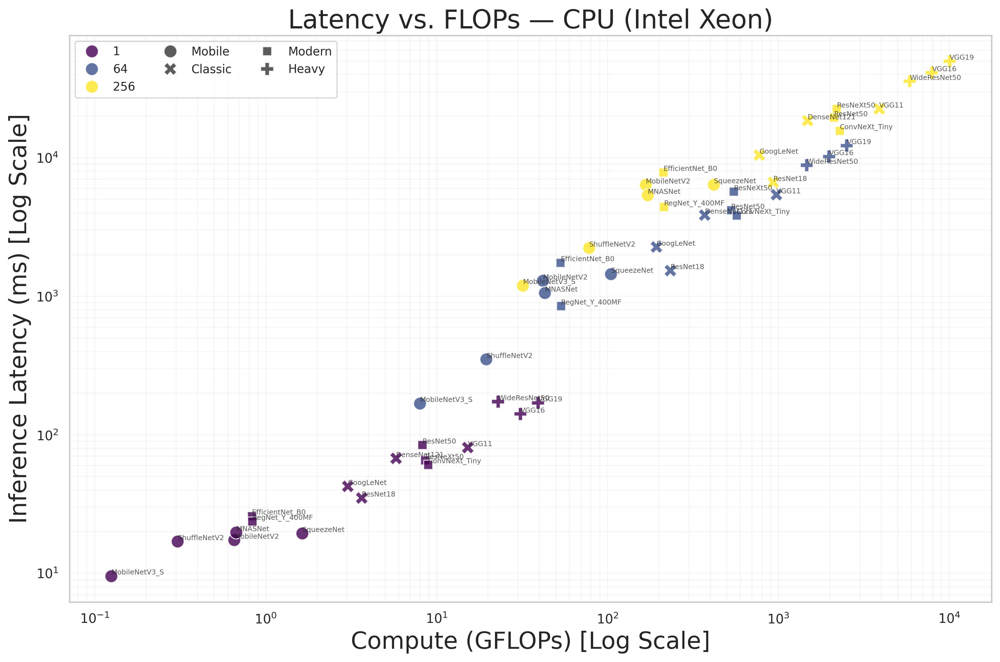

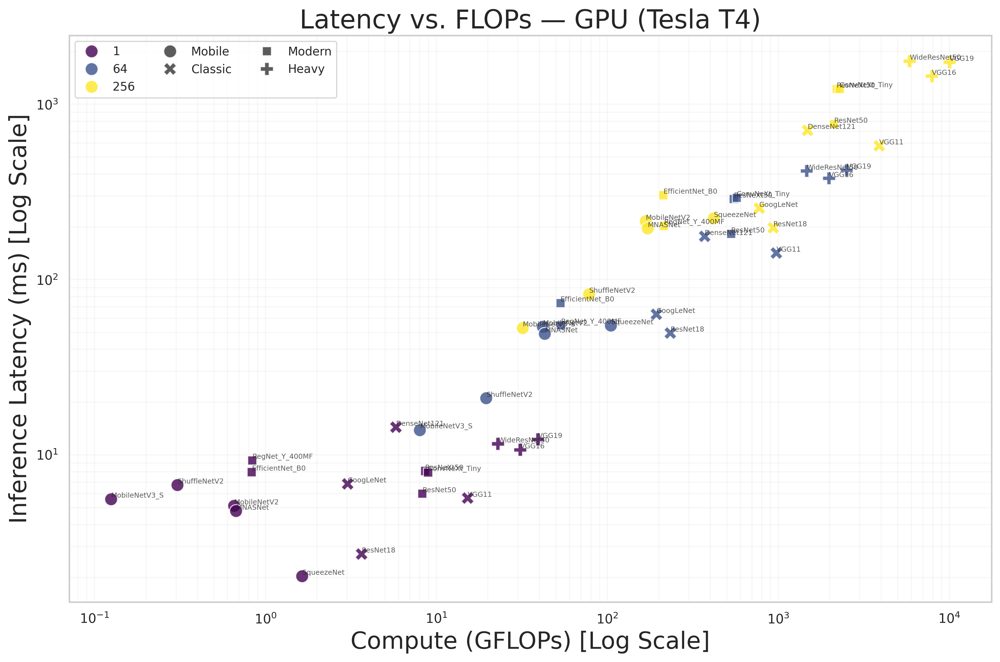


Task 3.2 — Latency vs Parameters


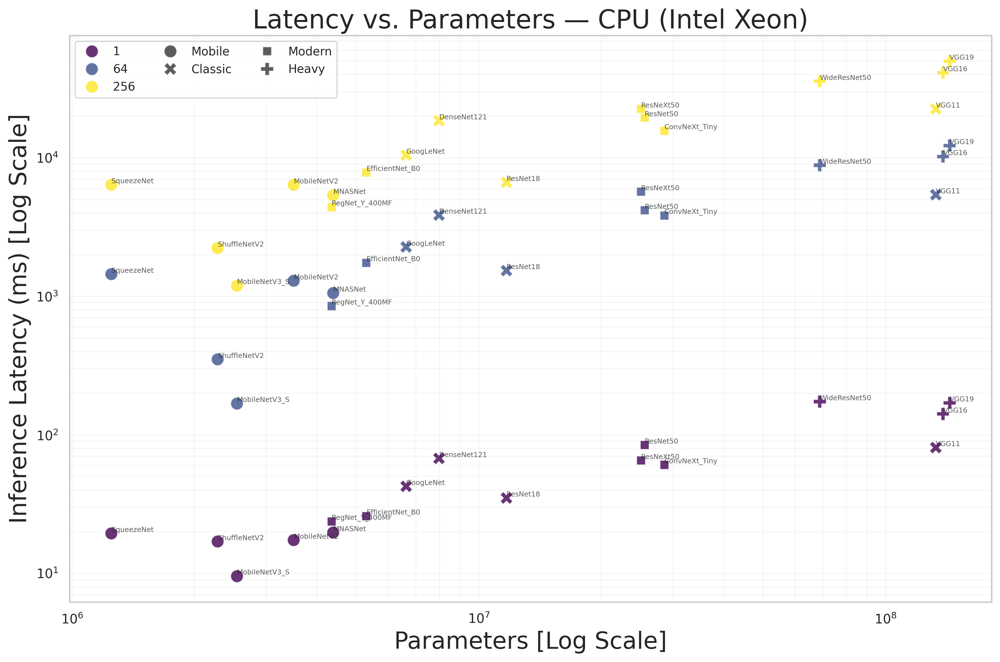

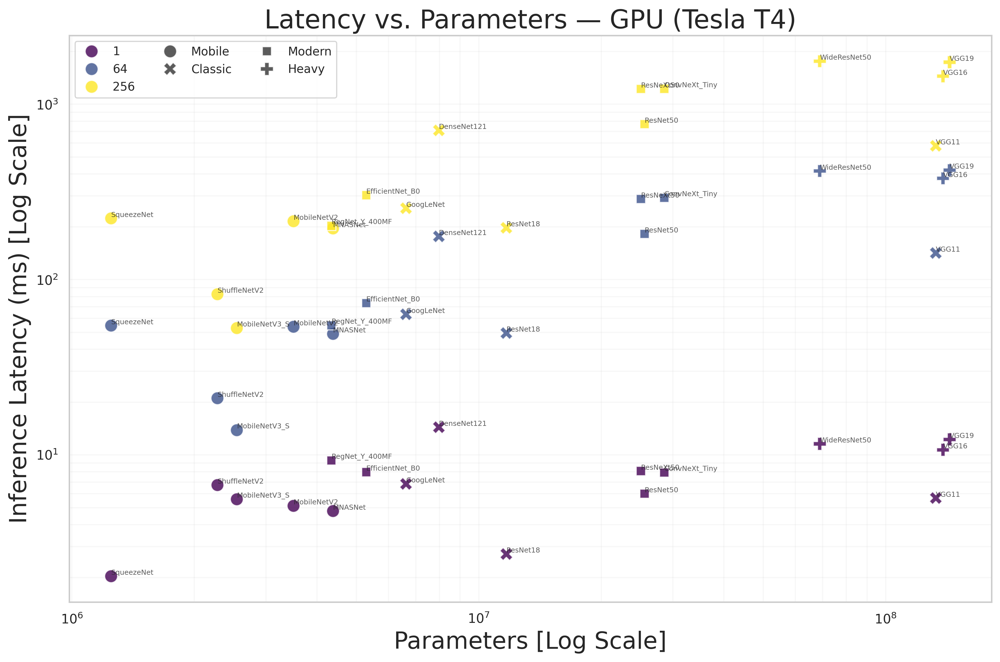


Task 3.3 — Spearman Rank Correlation


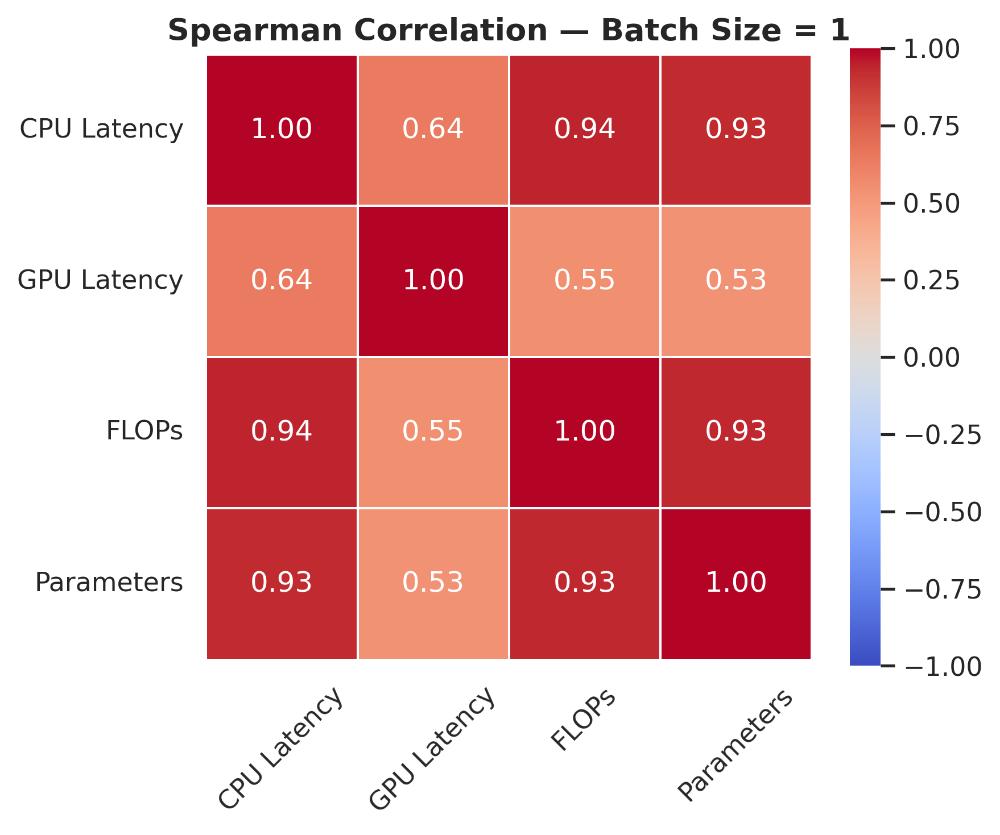

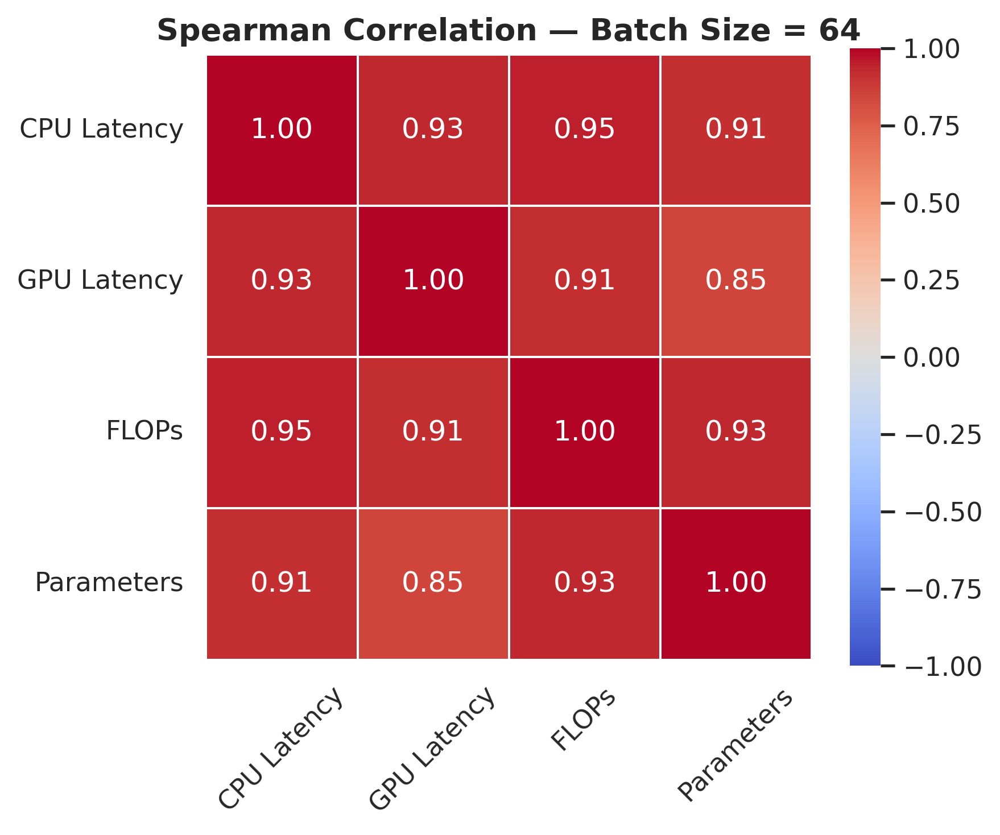

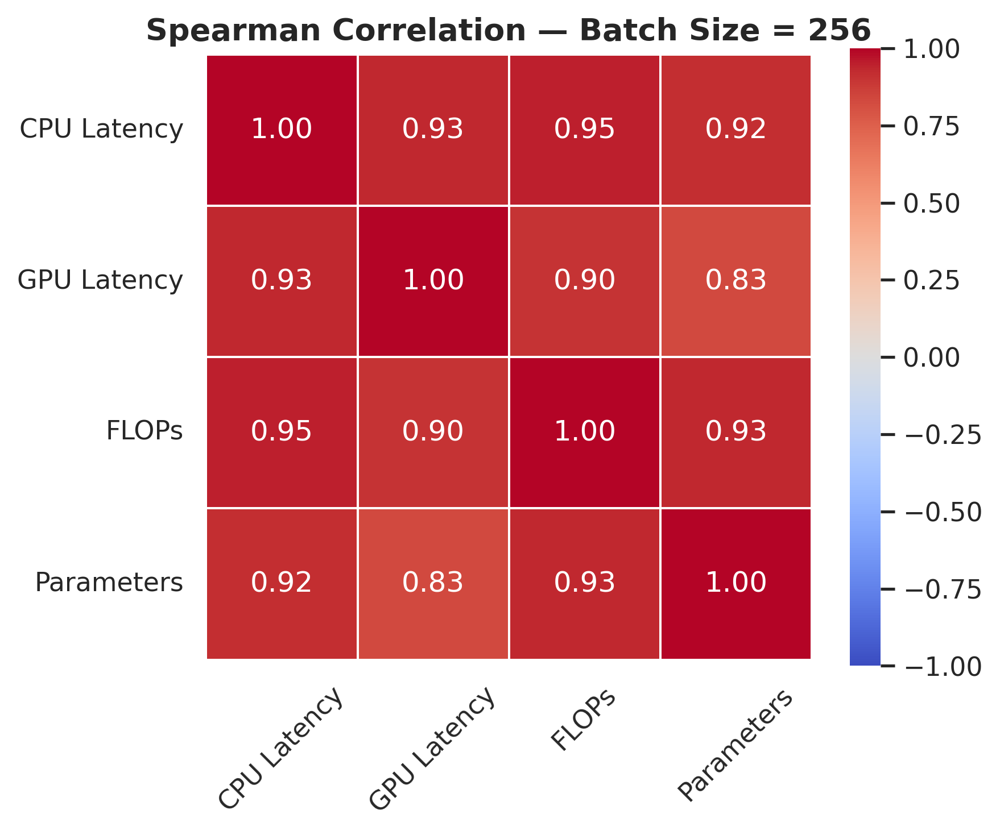

Task 3.4 — FLOPs / Parameters as Latency Predictors
  CPU Latency vs FLOPs:      0.944
  GPU Latency vs FLOPs:      0.549
  CPU Latency vs Parameters: 0.929
  GPU Latency vs Parameters: 0.534

Task 3.5 — Throughput


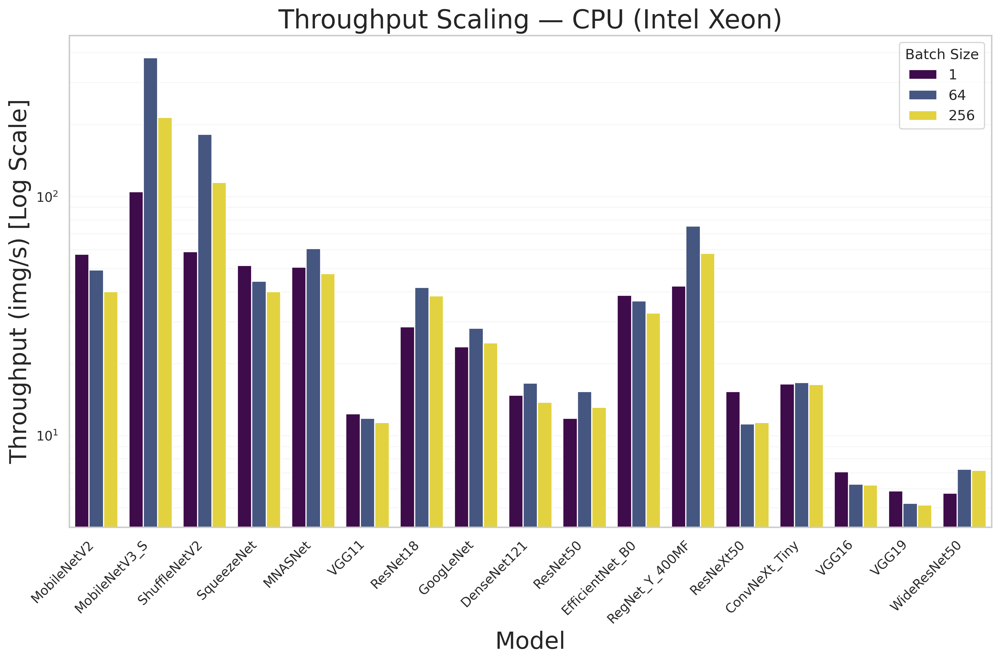

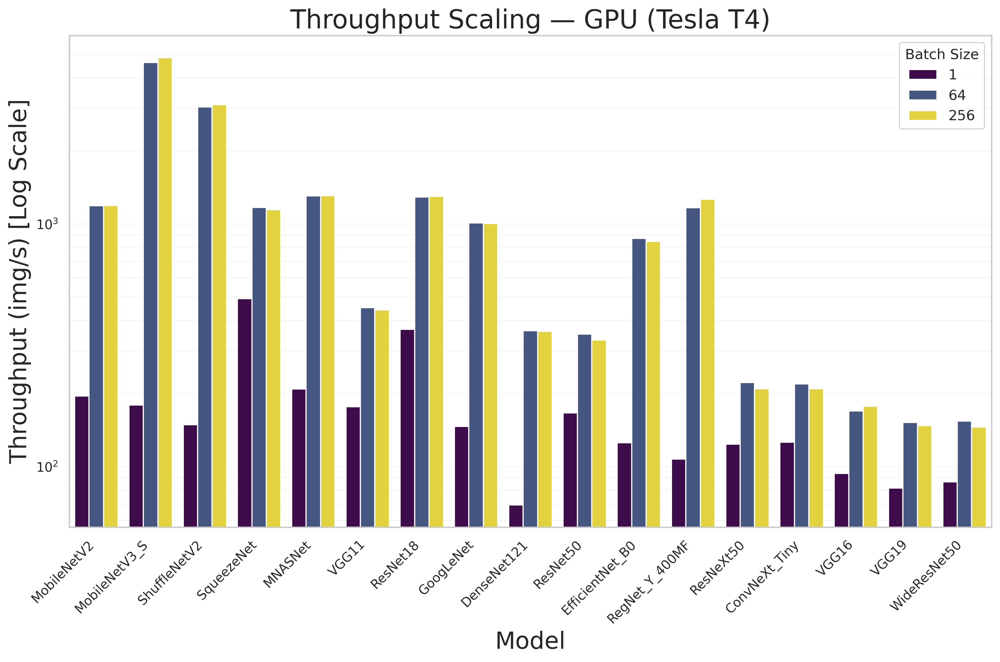

In [6]:
BATCH_SIZES = [1, 64, 256]
DEVICES     = ['cpu', 'cuda'] if torch.cuda.is_available() else ['cpu']
WARMUP_RUNS = 5
TIMED_RUNS  = 15

print(f"Available devices: {DEVICES}")
if 'cuda' in DEVICES:
    print(f"GPU: {torch.cuda.get_device_name(0)}")

def get_model_specs(model, input_shape=(1, 3, 224, 224)):
    model.to('cpu').eval()
    x = torch.randn(*input_shape)
    try:
        macs, params = profile(model, inputs=(x,), verbose=False)
        flops = 2 * macs
    except Exception:
        flops = 0
        params = sum(p.numel() for p in model.parameters())
    return flops, params


def measure_latency(model, device, batch_size,
                    input_shape=(3, 224, 224),
                    warmup=WARMUP_RUNS, runs=TIMED_RUNS):
    model.eval().to(device)
    x = torch.randn(batch_size, *input_shape).to(device)

    try:
        with torch.no_grad():
            for _ in range(warmup):
                model(x)
        if device == 'cuda':
            torch.cuda.synchronize()
    except RuntimeError as e:
        if 'out of memory' in str(e):
            print(f"  [OOM] {model.__class__.__name__} bs={batch_size} on {device} (warmup)")
            torch.cuda.empty_cache()
            return None
        raise

    latencies = []
    try:
        with torch.no_grad():
            if device == 'cuda':
                starter = torch.cuda.Event(enable_timing=True)
                ender = torch.cuda.Event(enable_timing=True)
                for _ in range(runs):
                    starter.record()
                    model(x)
                    ender.record()
                    torch.cuda.synchronize()
                    latencies.append(starter.elapsed_time(ender) / 1000)  # → seconds
            else:
                for _ in range(runs):
                    t0 = time.perf_counter()
                    model(x)
                    latencies.append(time.perf_counter() - t0)
    except RuntimeError as e:
        if 'out of memory' in str(e):
            print(f"  [OOM] {model.__class__.__name__} bs={batch_size} on {device}")
            torch.cuda.empty_cache()
            return None
        raise

    return float(np.median(latencies))

# Data collection
def collect_data():
    models_dict  = get_models()
    records      = []
    static_cache = {}

    print("Computing static metrics (FLOPs, OI, Parameters)...")
    dummy_input = torch.randn(1, 3, 224, 224)
    for name, (model, m_type) in models_dict.items():
        flops, params = get_model_specs(model)
        param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
        act_bytes = estimate_activation_bytes(model.to('cpu').eval(), dummy_input)
        mem_bytes = param_bytes + act_bytes
        oi = flops / mem_bytes if mem_bytes > 0 else 0
        static_cache[name] = (flops, oi, params, m_type)
        print(f"  {name:<20}  FLOPs={flops/1e9:.3f} G  "
              f"OI={oi:.2f}  Params={params/1e6:.2f} M")

    header = (f"{'Model':<20} | {'Device':<6} | {'Batch':>5} | "
              f"{'GFLOPs':>8} | {'Params(M)':>9} | {'Latency(s)':>10} | {'Throughput':>10}")
    print(header)
    print("-" * len(header))

    for device in DEVICES:
        dev_key = "GPU" if device == 'cuda' else "CPU"
        peak_flops = colab_specs[dev_key]['peak_flops']

        for name, (model, _) in models_dict.items():
            flops_b1, oi, params, m_type = static_cache[name]

            for bs in BATCH_SIZES:
                lat = measure_latency(model, device, bs)
                flops_total = flops_b1 * bs

                if lat is not None and lat > 0:
                    actual_gflops = (flops_total / lat) / 1e9
                    utilization = actual_gflops / peak_flops * 100
                    throughput = bs / lat
                    print(f"{name:<20} | {dev_key:<6} | {bs:>5} | "
                          f"{flops_total/1e9:>8.2f} | {params/1e6:>9.2f} | "
                          f"{lat:>10.4f} | {throughput:>10.1f}")
                else:
                    actual_gflops = utilization = throughput = np.nan
                    print(f"{name:<20} | {dev_key:<6} | {bs:>5} | OOM")

                records.append({
                    "Model": name,
                    "Type": m_type,
                    "Device": dev_key,
                    "Batch Size": bs,

                    "Operational Intensity": oi,
                    "Parameters": params,
                    "FLOPs": flops_total,
                    "GFLOPs": flops_total / 1e9,

                    "Latency (s)": lat if lat is not None else np.nan,
                    "Latency (ms)": lat * 1000 if lat is not None else np.nan,
                    "Throughput (img/s)": throughput,
                    "Actual GFLOPs": actual_gflops,
                    "Utilization": utilization,
                })

    return pd.DataFrame(records)

# Task 3.1 & 3.2 — Latency vs FLOPs / Params
def plot_latency_vs_metric(df, x_metric, x_label, title_suffix):
    df_clean = df.dropna(subset=["Latency (ms)"])

    for device_name in ["CPU", "GPU"]:
        df_dev = df_clean[df_clean["Device"] == device_name]
        if df_dev.empty:
            continue

        display_name = "GPU (Tesla T4)" if device_name == "GPU" else "CPU (Intel Xeon)"

        plt.figure(figsize=(12, 8))

        sns.scatterplot(
            data=df_dev,
            x=x_metric, y="Latency (ms)",
            hue="Batch Size", style="Type",
            s=120, alpha=0.8,
            palette="viridis",
            legend="full"
        )

        for _, row in df_dev.iterrows():
            plt.text(
                row[x_metric], row["Latency (ms)"],
                row["Model"],
                fontsize=6, alpha=0.75,
                ha='left', va='bottom'
            )

        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel(x_label, fontsize=20)
        plt.ylabel("Inference Latency (ms) [Log Scale]", fontsize=20)
        plt.title(f"Latency vs. {title_suffix} — {display_name}", fontsize=22)

        handles, labels = plt.gca().get_legend_handles_labels()
        filtered = [(h, l) for h, l in zip(handles, labels)
                    if l not in ("Type", "Batch Size")]
        if filtered:
            h_f, l_f = zip(*filtered)
            plt.legend(h_f, l_f, loc='upper left', fontsize=10, ncol=3, frameon=True)

        plt.grid(True, which="both", alpha=0.15)
        plt.tight_layout()
        fname = (f"task3_latency_{title_suffix.lower().replace(' ','_')}"
                 f"_{device_name.lower()}.png")
        plt.savefig(fname, bbox_inches='tight', dpi=150)
        plt.show()

# Task 3.3 — Spearman rank correlation matrix
def plot_correlation_heatmap(df):
    df_clean = df.dropna(subset=["Latency (s)"])
    specs = (df_clean[df_clean["Batch Size"] == 1]
             [["Model", "GFLOPs", "Parameters"]]
             .drop_duplicates()
             .set_index("Model")
             .rename(columns={"GFLOPs": "FLOPs"}))

    corr_b1 = None

    for bs in BATCH_SIZES:
        df_bs = df_clean[df_clean["Batch Size"] == bs]

        df_pivot = df_bs.pivot_table(
            index="Model", columns="Device",
            values="Latency (s)", aggfunc="median"
        )

        rename = {}
        for col in df_pivot.columns:
            if   "CPU"  in col.upper():                         rename[col] = "CPU Latency"
            elif "CUDA" in col.upper() or "GPU" in col.upper(): rename[col] = "GPU Latency"
        df_pivot = df_pivot.rename(columns=rename)

        df_corr_data = df_pivot.join(specs)
        corr = df_corr_data.corr(method="spearman")

        if bs == 1:
            corr_b1 = corr

        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(
            corr,
            annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            annot_kws={"fontsize": 12, "rotation": 0},
            ax=ax
        )
        ax.set_title(f"Spearman Correlation — Batch Size = {bs}",
                     fontsize=13, fontweight='bold')
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)
        plt.tight_layout()
        plt.savefig(f"task3_correlation_bs{bs}.png", bbox_inches='tight', dpi=150)
        plt.show()

    return corr_b1

# Task 3.5 — Throughput at different batch sizes
def plot_throughput(df):
    df_clean = df.dropna(subset=["Throughput (img/s)"])

    for device_name in ["CPU", "GPU"]:
        df_dev = df_clean[df_clean["Device"] == device_name]
        if df_dev.empty:
            continue

        display_name = "GPU (Tesla T4)" if device_name == "GPU" else "CPU (Intel Xeon)"

        plt.figure(figsize=(12, 8))

        sns.barplot(
            data=df_dev,
            x="Model", y="Throughput (img/s)",
            hue="Batch Size",
            palette="viridis"
        )

        plt.yscale("log")
        plt.xlabel("Model", fontsize=20)
        plt.ylabel("Throughput (img/s) [Log Scale]", fontsize=20)
        plt.title(f"Throughput Scaling — {display_name}", fontsize=22)
        plt.xticks(rotation=45, ha="right", fontsize=11)
        plt.grid(True, which="both", axis='y', alpha=0.15)
        plt.legend(title="Batch Size", loc='upper right', fontsize=12, frameon=True)
        plt.tight_layout()
        plt.savefig(f"task3_throughput_{device_name.lower()}.png", bbox_inches='tight', dpi=150)
        plt.show()

# Task 3.4 — Commentary helper (text output)
def print_task_3_4_analysis(corr):
    print("Task 3.4 — FLOPs / Parameters as Latency Predictors")

    def safe_loc(matrix, r, c):
        try:
            return matrix.loc[r, c]
        except KeyError:
            return float('nan')

    cpu_flops = safe_loc(corr, "CPU Latency", "FLOPs")
    gpu_flops = safe_loc(corr, "GPU Latency", "FLOPs")
    cpu_param = safe_loc(corr, "CPU Latency", "Parameters")
    gpu_param = safe_loc(corr, "GPU Latency", "Parameters")

    print(f"  CPU Latency vs FLOPs:      {cpu_flops:.3f}")
    print(f"  GPU Latency vs FLOPs:      {gpu_flops:.3f}")
    print(f"  CPU Latency vs Parameters: {cpu_param:.3f}")
    print(f"  GPU Latency vs Parameters: {gpu_param:.3f}")

if __name__ == "__main__":
    df_results = collect_data()

    print("\nTask 3.1 — Latency vs FLOPs")
    plot_latency_vs_metric(df_results, "GFLOPs",     "Compute (GFLOPs) [Log Scale]", "FLOPs")

    print("\nTask 3.2 — Latency vs Parameters")
    plot_latency_vs_metric(df_results, "Parameters", "Parameters [Log Scale]",       "Parameters")

    print("\nTask 3.3 — Spearman Rank Correlation")
    corr_matrix = plot_correlation_heatmap(df_results)

    if corr_matrix is not None:
        print_task_3_4_analysis(corr_matrix)

    print("\nTask 3.5 — Throughput")
    plot_throughput(df_results)

# 4. Hardware Utilization and Peak Performance

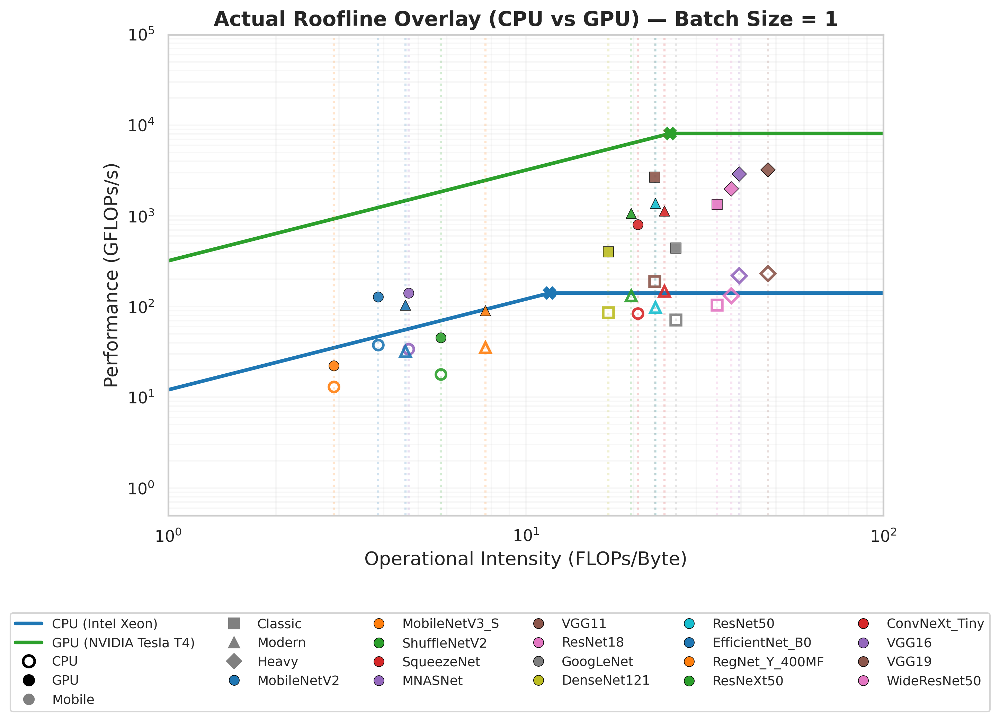

Saved: task4_roofline_bs1.png


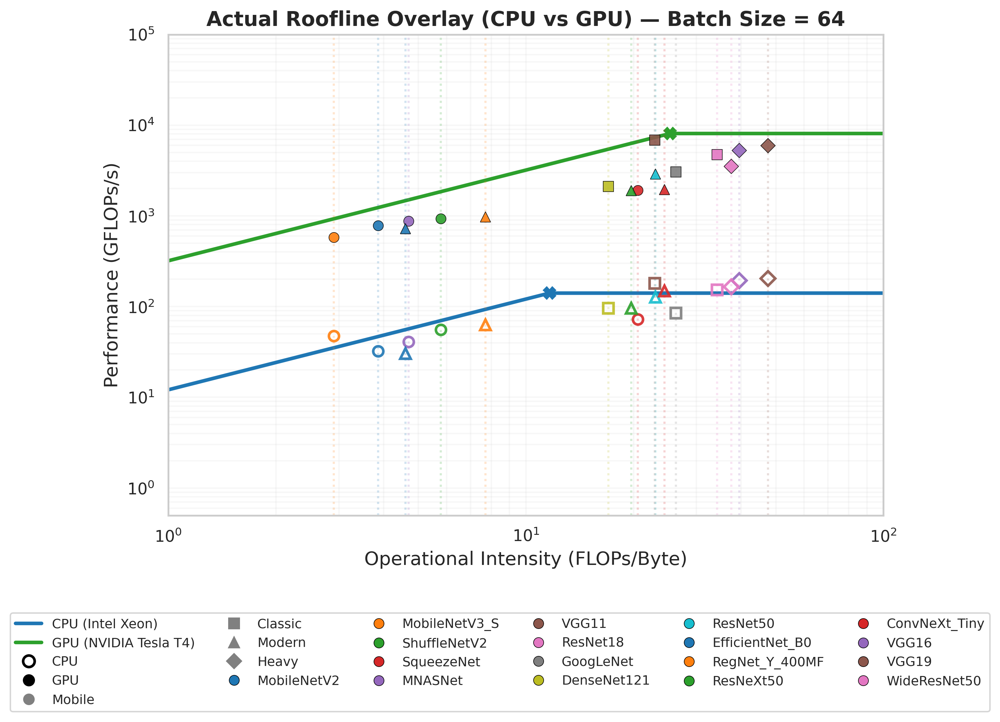

Saved: task4_roofline_bs64.png


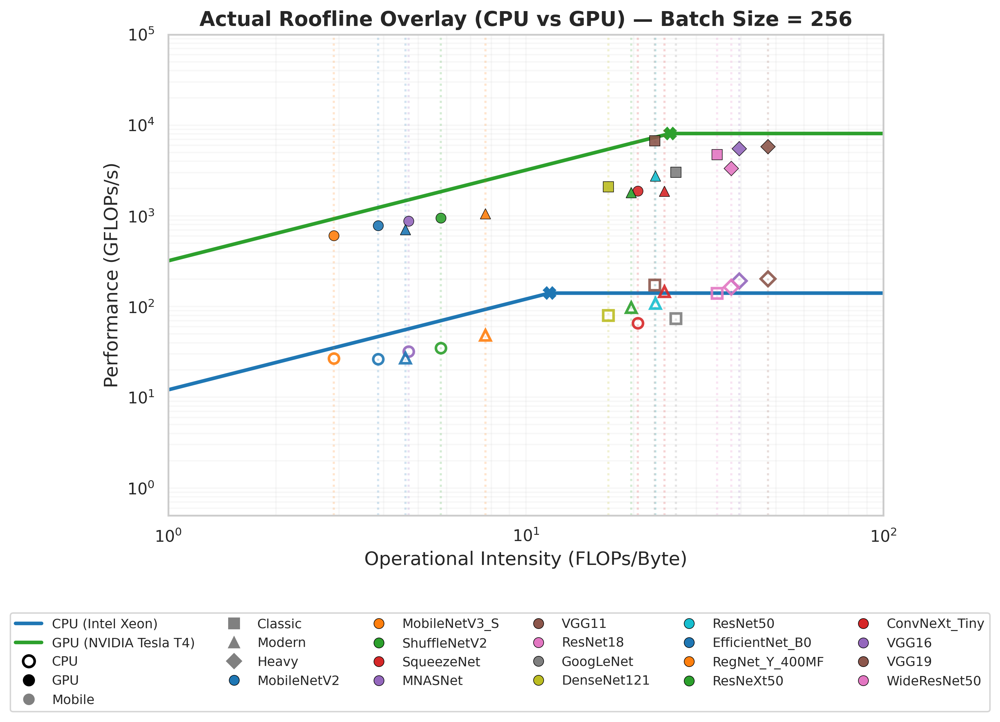

Saved: task4_roofline_bs256.png


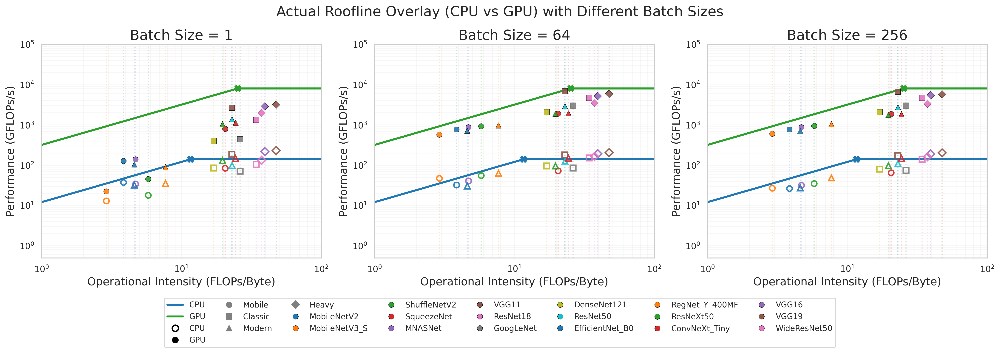


Task 4.2 — Gap Between Peak and Achieved Performance

  [CPU]  Peak = 140.8 GFLOPs/s
    Best  utilization: VGG19                BS=1  →  163.83%
    Worst utilization: MobileNetV3_S        BS=1  →  9.30%
    Mean  utilization: 70.92%

  [GPU]  Peak = 8100 GFLOPs/s
    Best  utilization: VGG11                BS=64  →  84.89%
    Worst utilization: MobileNetV3_S        BS=1  →  0.28%
    Mean  utilization: 25.99%


In [13]:
def _pick_col(df, candidates, desc="column"):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find {desc}. Tried {candidates}. Available: {list(df.columns)}")

def plot_combined_actual_batches(
    df_actual,
    colab_specs,
    batch_sizes=(1, 64, 256),
    xmin=1, xmax=100,
    ymin=1, ymax=20000,
    connect_cpu_gpu_same_model=False,
    legend_outside=True
):
    oi_col    = _pick_col(df_actual, ["Operational Intensity", "Op_Intensity"], desc="OI")
    perf_col  = _pick_col(df_actual, ["Actual GFLOPs", "Actual_GFLOPs"], desc="Actual GFLOPs")
    bs_col    = _pick_col(df_actual, ["Batch Size", "Batch_Size"], desc="Batch Size")
    dev_col   = _pick_col(df_actual, ["Device"], desc="Device")
    type_col  = _pick_col(df_actual, ["Type"], desc="Type")
    model_col = _pick_col(df_actual, ["Model"], desc="Model")

    df_clean = df_actual.dropna(subset=[oi_col, perf_col, bs_col, dev_col, model_col]).copy()
    df_clean[dev_col] = df_clean[dev_col].replace({"cuda": "GPU", "CUDA": "GPU"})

    if df_clean.empty:
        print("No valid data to plot.")
        return

    all_models  = df_clean[model_col].unique().tolist()
    palette     = sns.color_palette("tab10", n_colors=len(all_models))
    model2color = {m: palette[i] for i, m in enumerate(all_models)}
    markers     = {"Mobile": "o", "Classic": "s", "Modern": "^", "Heavy": "D"}

    xgrid = np.logspace(np.log10(xmin), np.log10(xmax), 1000)

    # ── build legend handles once ────────────────────────────
    roof_handles = [
        Line2D([0], [0], color=spec["color"], lw=2.5, label=hw_name)
        for hw_name, spec in colab_specs.items()
        if hw_name not in ("CPU", "GPU")   # exclude short aliases
    ]
    device_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='none', markeredgecolor='black', markeredgewidth=1.8,
               markersize=8, label='CPU'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='black', markeredgecolor='black', markeredgewidth=0.4,
               markersize=8, label='GPU'),
    ]
    type_handles = [
        Line2D([0], [0], marker='o', linestyle='None', color='gray',
               markerfacecolor='gray', markersize=7, label='Mobile'),
        Line2D([0], [0], marker='s', linestyle='None', color='gray',
               markerfacecolor='gray', markersize=7, label='Classic'),
        Line2D([0], [0], marker='^', linestyle='None', color='gray',
               markerfacecolor='gray', markersize=7, label='Modern'),
        Line2D([0], [0], marker='D', linestyle='None', color='gray',
               markerfacecolor='gray', markersize=7, label='Heavy'),
    ]
    model_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor=model2color[m], markeredgecolor='black',
               markeredgewidth=0.4, markersize=7, label=m)
        for m in all_models
    ]
    all_handles = roof_handles + device_handles + type_handles + model_handles

    # ── one figure per batch size ────────────────────────────
    for bs in batch_sizes:
        sub = df_clean[df_clean[bs_col] == bs]

        fig, ax = plt.subplots(figsize=(8, 7))
        ax.set_title(f"Actual Roofline Overlay (CPU vs GPU) — Batch Size = {bs}",
                     fontsize=14, fontweight='bold')

        for hw_name, spec in colab_specs.items():
            if hw_name in ("CPU", "GPU"):   # skip aliases
                continue
            peak  = spec["peak_flops"]
            bw    = spec["bandwidth"]
            color = spec["color"]
            y     = np.minimum(peak, bw * xgrid)
            ax.plot(xgrid, y, color=color, linewidth=2.5, label=hw_name)
            ridge = peak / bw
            ax.plot(ridge, peak, "X", color=color, markersize=8)

        for m in all_models:
            sub_m = sub[sub[model_col] == m]
            if sub_m.empty:
                continue
            oi_val = float(np.median(sub_m[oi_col].values))
            ax.vlines(x=oi_val, ymin=ymin, ymax=ymax,
                      colors=model2color[m], linestyles=":", alpha=0.20)

        for _, row in sub.iterrows():
            oi     = float(row[oi_col])
            actual = float(row[perf_col])
            m      = row[model_col]
            t      = row.get(type_col, None)
            device = str(row[dev_col]).upper()

            base_color = model2color[m]
            marker     = markers.get(t, "o")

            if device == "CPU":
                mfc, mec, mew = "none", base_color, 1.8
            else:
                mfc, mec, mew = base_color, "black", 0.4

            ax.plot(
                oi, actual,
                marker=marker, linestyle="None", markersize=7,
                markerfacecolor=mfc, markeredgecolor=mec,
                markeredgewidth=mew, alpha=0.9
            )

        if connect_cpu_gpu_same_model:
            for m in all_models:
                sub_m    = sub[sub[model_col] == m]
                cpu_rows = sub_m[sub_m[dev_col].str.upper() == "CPU"]
                gpu_rows = sub_m[sub_m[dev_col].str.upper() == "GPU"]
                if cpu_rows.empty or gpu_rows.empty:
                    continue
                x1 = float(np.median(cpu_rows[oi_col]))
                y1 = float(np.median(cpu_rows[perf_col]))
                x2 = float(np.median(gpu_rows[oi_col]))
                y2 = float(np.median(gpu_rows[perf_col]))
                ax.plot([x1, x2], [y1, y2],
                        linestyle="--", linewidth=1, alpha=0.35,
                        color=model2color[m])

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(True, which="both", alpha=0.15)
        ax.set_xlabel("Operational Intensity (FLOPs/Byte)", fontsize=13)
        ax.set_ylabel("Performance (GFLOPs/s)", fontsize=13)

        if legend_outside:
            fig.legend(handles=all_handles, loc="lower center", ncol=6,
                       fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.0))
            plt.tight_layout(rect=[0, 0.18, 1, 1])
        else:
            ax.legend(handles=all_handles, loc="lower right",
                      fontsize=8, ncol=2, frameon=True)
            plt.tight_layout()

        fname = f"task4_roofline_bs{bs}.png"
        plt.savefig(fname, bbox_inches='tight', dpi=150)
        plt.show()
        print(f"Saved: {fname}")

def plot_combined_actual_batches_parallel(
    df_actual,
    colab_specs,
    batch_sizes=(1, 64, 256),
    ncols=3,
    xmin=1, xmax=100,
    ymin=1, ymax=20000,
    connect_cpu_gpu_same_model=False,
    legend_outside=True
):
    oi_col = _pick_col(df_actual, ["Operational Intensity", "Op_Intensity"], desc="OI")
    perf_col = _pick_col(df_actual, ["Actual GFLOPs", "Actual_GFLOPs"], desc="Actual GFLOPs")
    bs_col = _pick_col(df_actual, ["Batch Size", "Batch_Size"], desc="Batch Size")
    dev_col = _pick_col(df_actual, ["Device"], desc="Device")
    type_col = _pick_col(df_actual, ["Type"], desc="Type")
    model_col = _pick_col(df_actual, ["Model"], desc="Model")

    df_clean = df_actual.dropna(subset=[oi_col, perf_col, bs_col, dev_col, model_col]).copy()
    df_clean[dev_col] = df_clean[dev_col].replace({"cuda": "GPU", "CUDA": "GPU"})

    if df_clean.empty:
        print("No valid data to plot.")
        return

    all_models = df_clean[model_col].unique().tolist()
    palette = sns.color_palette("tab10", n_colors=len(all_models))
    model2color = {m: palette[i] for i, m in enumerate(all_models)}
    markers = {"Mobile": "o", "Classic": "s", "Modern": "^", "Heavy": "D"}

    n = len(batch_sizes)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 6 * nrows))
    if nrows * ncols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    xgrid = np.logspace(np.log10(xmin), np.log10(xmax), 1000)

    for idx, bs in enumerate(batch_sizes):
        ax  = axes[idx]
        sub = df_clean[df_clean[bs_col] == bs]
        ax.set_title(f"Batch Size = {bs}", fontsize=18)

        for hw_name, spec in colab_specs.items():
            peak = spec["peak_flops"]
            bw = spec["bandwidth"]
            color = spec["color"]
            y = np.minimum(peak, bw * xgrid)
            ax.plot(xgrid, y, color=color, linewidth=2.5, label=hw_name)
            ridge = peak / bw
            ax.plot(ridge, peak, "X", color=color, markersize=8)

        for m in all_models:
            sub_m = sub[sub[model_col] == m]
            if sub_m.empty:
                continue
            oi_val = float(np.median(sub_m[oi_col].values))
            ax.vlines(x=oi_val, ymin=ymin, ymax=ymax,
                      colors=model2color[m], linestyles=":", alpha=0.20)

        for _, row in sub.iterrows():
            oi = float(row[oi_col])
            actual = float(row[perf_col])
            m = row[model_col]
            t = row.get(type_col, None)
            device = str(row[dev_col]).upper()

            base_color = model2color[m]
            marker = markers.get(t, "o")

            if device == "CPU":
                mfc, mec, mew = "none", base_color, 1.8
            else:
                mfc, mec, mew = base_color, "black", 0.4

            ax.plot(
                oi, actual,
                marker=marker, linestyle="None", markersize=7,
                markerfacecolor=mfc, markeredgecolor=mec,
                markeredgewidth=mew, alpha=0.9
            )

        if connect_cpu_gpu_same_model:
            for m in all_models:
                sub_m = sub[sub[model_col] == m]
                cpu_rows = sub_m[sub_m[dev_col].str.upper() == "CPU"]
                gpu_rows = sub_m[sub_m[dev_col].str.upper() == "GPU"]
                if cpu_rows.empty or gpu_rows.empty:
                    continue
                x1 = float(np.median(cpu_rows[oi_col]))
                y1 = float(np.median(cpu_rows[perf_col]))
                x2 = float(np.median(gpu_rows[oi_col]))
                y2 = float(np.median(gpu_rows[perf_col]))
                ax.plot([x1, x2], [y1, y2],
                        linestyle="--", linewidth=1, alpha=0.35,
                        color=model2color[m])

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(True, which="both", alpha=0.15)
        ax.set_xlabel("Operational Intensity (FLOPs/Byte)", fontsize=14)
        ax.set_ylabel("Performance (GFLOPs/s)", fontsize=14)

    for j in range(len(batch_sizes), len(axes)):
        axes[j].axis("off")

    fig.suptitle("Actual Roofline Overlay (CPU vs GPU) with Different Batch Sizes",
                 fontsize=18, y=0.95)

    roof_handles = [
        Line2D([0], [0], color=spec["color"], lw=2.5, label=hw_name)
        for hw_name, spec in colab_specs.items()
        if hw_name not in ("CPU (Intel Xeon)", "GPU (NVIDIA Tesla T4)")
    ]
    device_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='none', markeredgecolor='black', markeredgewidth=1.8,
               markersize=8, label='CPU'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='black', markeredgecolor='black', markeredgewidth=0.4,
               markersize=8, label='GPU'),
    ]
    type_handles = [
        Line2D([0], [0], marker='o', linestyle='None', color='gray',
               markerfacecolor='gray', markersize=7, label='Mobile'),
        Line2D([0], [0], marker='s', linestyle='None', color='gray',
               markerfacecolor='gray', markersize=7, label='Classic'),
        Line2D([0], [0], marker='^', linestyle='None', color='gray',
               markerfacecolor='gray', markersize=7, label='Modern'),
        Line2D([0], [0], marker='D', linestyle='None', color='gray',
               markerfacecolor='gray', markersize=7, label='Heavy'),
    ]
    model_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor=model2color[m], markeredgecolor='black',
               markeredgewidth=0.4, markersize=7, label=m)
        for m in all_models
    ]
    all_handles = roof_handles + device_handles + type_handles + model_handles

    if legend_outside:
        fig.legend(handles=all_handles, loc="lower center", ncol=8,
                   fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.08))
        plt.tight_layout(rect=[0, 0.08, 1, 0.98])
    else:
        axes[0].legend(handles=all_handles, loc="lower right",
                       fontsize=9, ncol=2, frameon=True)
        plt.tight_layout(rect=[0, 0.02, 1, 0.98])

    plt.savefig("task4_roofline_actual.png", bbox_inches='tight', dpi=150)
    plt.show()

def print_gap_analysis(df):
    print("\n" + "=" * 60)
    print("Task 4.2 — Gap Between Peak and Achieved Performance")
    print("=" * 60)

    for dev_key in ["CPU", "GPU"]:
        df_dev = df[df["Device"] == dev_key].dropna(subset=["Utilization"])
        if df_dev.empty:
            continue
        peak = colab_specs[dev_key]["peak_flops"]
        best  = df_dev.loc[df_dev["Utilization"].idxmax()]
        worst = df_dev.loc[df_dev["Utilization"].idxmin()]
        mean_util = df_dev["Utilization"].mean()
        print(f"\n  [{dev_key}]  Peak = {peak} GFLOPs/s")
        print(f"    Best  utilization: {best['Model']:<20} "
              f"BS={int(best['Batch Size'])}  →  {best['Utilization']:.2f}%")
        print(f"    Worst utilization: {worst['Model']:<20} "
              f"BS={int(worst['Batch Size'])}  →  {worst['Utilization']:.2f}%")
        print(f"    Mean  utilization: {mean_util:.2f}%")

if __name__ == "__main__":

    plot_combined_actual_batches(
        df_results, colab_specs,
        batch_sizes=(1, 64, 256),
        xmin=1, xmax=100,
        ymin=0.5, ymax=100000,
        connect_cpu_gpu_same_model=False,
        legend_outside=True
    )

    plot_combined_actual_batches_parallel(
        df_results, colab_specs,
        batch_sizes=(1, 64, 256),
        xmin=1, xmax=100,
        ymin=0.5, ymax=100000,
        connect_cpu_gpu_same_model=False,
        legend_outside=True
    )
    print_gap_analysis(df_results)

# 5. Inference vs training

Using device: cuda

Forward vs Backward FLOPs and Latency

[ResNet-18]
  Fwd:   57.80 ms   Bwd:  132.60 ms   Ratio(bwd/fwd): 2.29x
  Fwd:    3.65 GF   Bwd:    7.30 GF   Ratio(bwd/fwd): 2.00x

[ResNet-50]
  Fwd:  219.10 ms   Bwd:  464.32 ms   Ratio(bwd/fwd): 2.12x
  Fwd:    8.26 GF   Bwd:   16.53 GF   Ratio(bwd/fwd): 2.00x

[VGG-19]
  Fwd:  410.17 ms   Bwd:  762.24 ms   Ratio(bwd/fwd): 1.86x
  Fwd:   39.38 GF   Bwd:   78.76 GF   Ratio(bwd/fwd): 2.00x

[MobileNetV2]
  Fwd:   84.38 ms   Bwd:  167.91 ms   Ratio(bwd/fwd): 1.99x
  Fwd:    0.64 GF   Bwd:    1.28 GF   Ratio(bwd/fwd): 2.00x

[EfficientNet-B0]
  Fwd:  102.29 ms   Bwd:  226.24 ms   Ratio(bwd/fwd): 2.21x
  Fwd:    0.82 GF   Bwd:    1.64 GF   Ratio(bwd/fwd): 2.00x


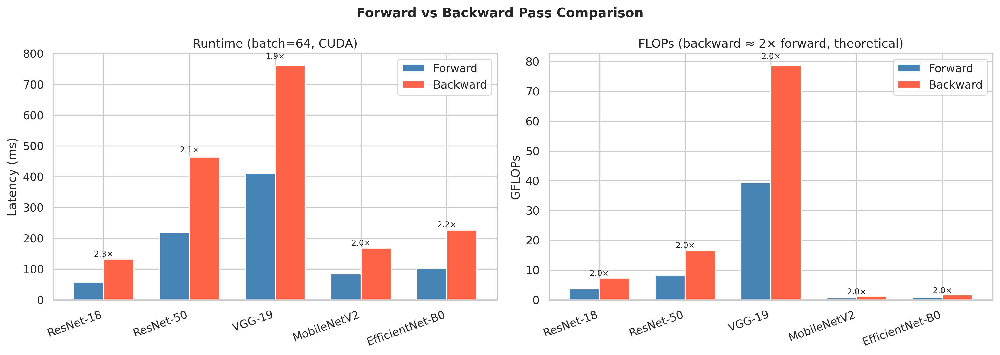


TASK 5.2 — Per-Layer-Type Breakdown (Latency, FLOPs, Memory)

Profiling: ResNet-18


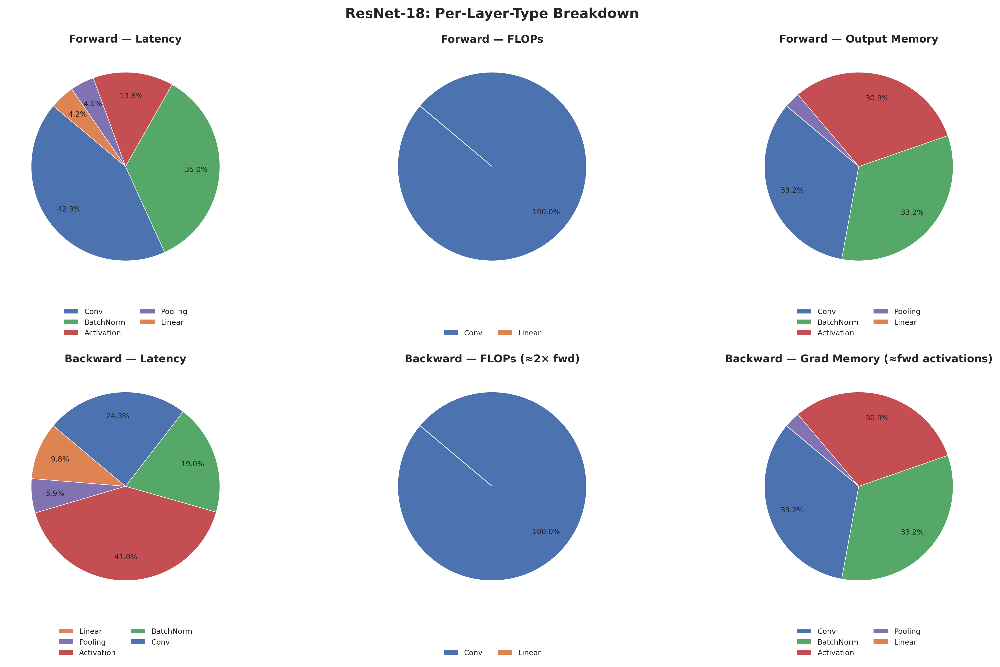


Profiling: VGG-19


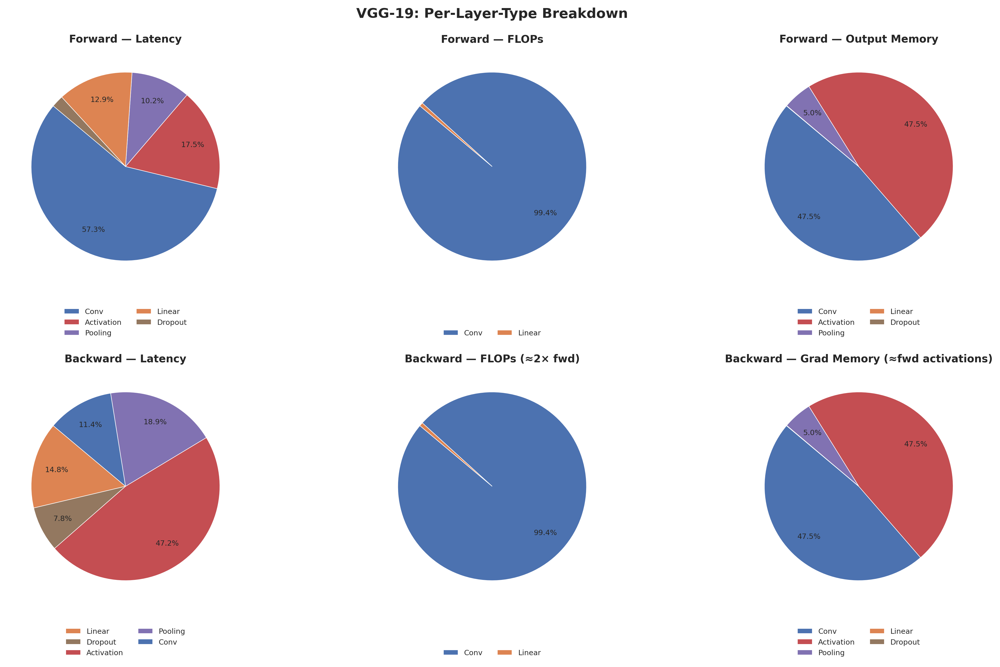


Profiling: ResNet-50


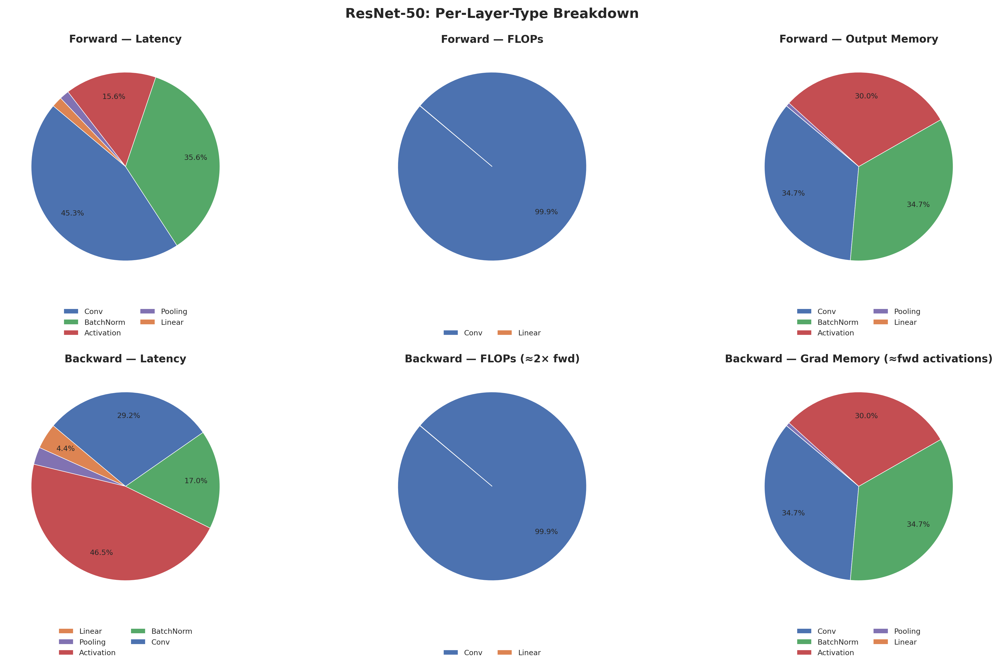


Profiling: MobileNetV2


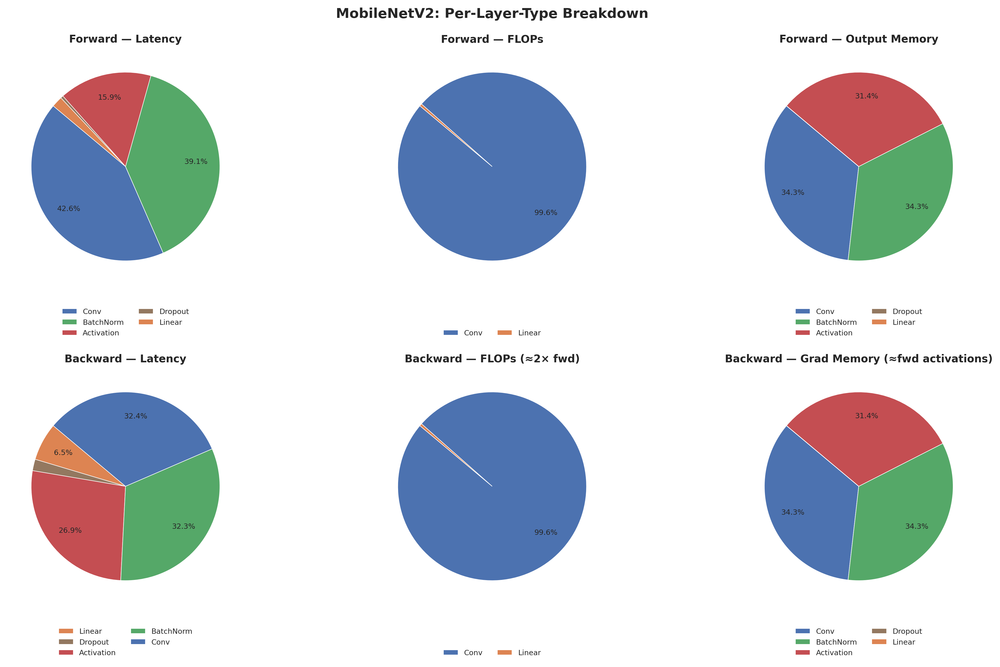


Profiling: EfficientNet-B0


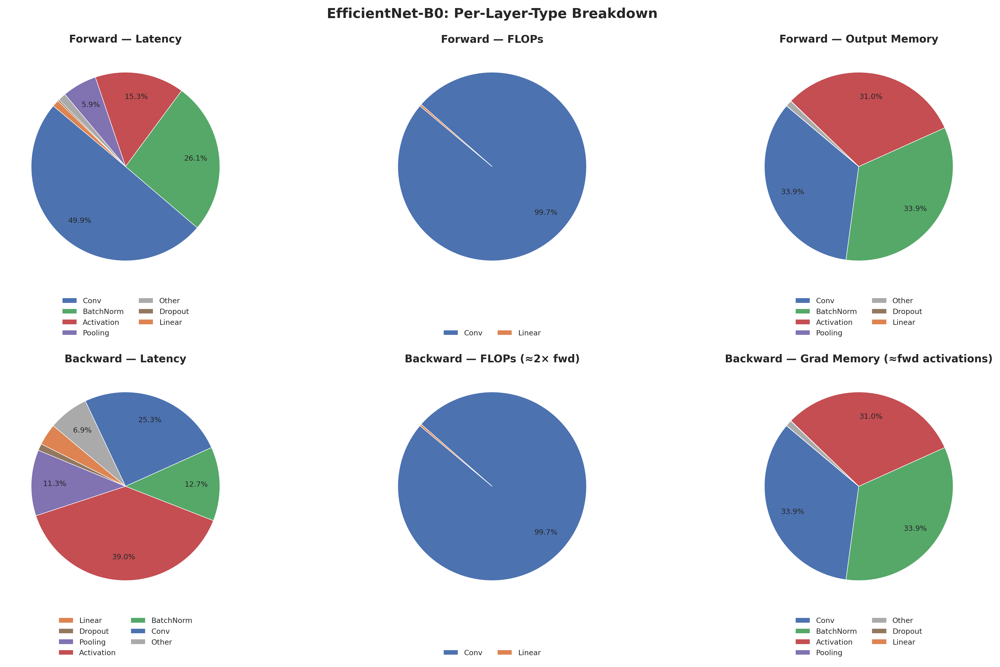

In [8]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

TRAIN_BATCH_SIZE = 64
INPUT_SIZE = (3, 224, 224)
WARMUP = 1
REPEATS = 3
NUM_CLASSES = 1000

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

SELECTED_MODELS = {
    'ResNet-18': models.resnet18,
    'ResNet-50': models.resnet50,
    'VGG-19': models.vgg19,
    'MobileNetV2': models.mobilenet_v2,
    'EfficientNet-B0': models.efficientnet_b0,
}

def sync():
    if DEVICE == 'cuda':
        torch.cuda.synchronize()

def timed_event(fn):
    if DEVICE == 'cuda':
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        fn()
        end.record()
        torch.cuda.synchronize()
        return start.elapsed_time(end)  # ms
    else:
        t0 = time.perf_counter()
        fn()
        return (time.perf_counter() - t0) * 1000  # ms

def measure_forward_backward(model, x, y, criterion):
    model.train()

    for _ in range(WARMUP):
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        model.zero_grad()
    sync()

    fwd_times, bwd_times = [], []

    for _ in range(REPEATS):
        model.zero_grad()
        fwd_times.append(timed_event(lambda: model(x)))

        out = model(x)
        loss = criterion(out, y)
        bwd_times.append(timed_event(lambda: loss.backward()))
        model.zero_grad()

    return float(np.mean(fwd_times)), float(np.mean(bwd_times))

def get_flops_giga(model_fn):
    m = model_fn(weights=None).to(DEVICE)
    macs, _ = get_model_complexity_info(
        m, INPUT_SIZE, as_strings=False,
        print_per_layer_stat=False, verbose=False
    )
    gflops_fwd = (macs * 2) / 1e9
    return gflops_fwd, gflops_fwd * 2


def classify_layer(module):
    n = type(module).__name__
    if 'Conv'      in n: return 'Conv'
    if 'Linear'    in n: return 'Linear'
    if 'BatchNorm' in n: return 'BatchNorm'
    if any(k in n for k in ('ReLU','Sigmoid','SiLU','GELU','Hardswish','Mish','ELU','Tanh')):
        return 'Activation'
    if 'Pool'      in n: return 'Pooling'
    if 'Dropout'   in n: return 'Dropout'
    return 'Other'

print("\n" + "=" * 60)
print("Forward vs Backward FLOPs and Latency")
print("=" * 60)

criterion = nn.CrossEntropyLoss()
results = {}

for name, model_fn in SELECTED_MODELS.items():
    print(f"\n[{name}]")
    model = model_fn(weights=None).to(DEVICE)
    x = torch.randn(TRAIN_BATCH_SIZE, *INPUT_SIZE).to(DEVICE)
    y = torch.randint(0, NUM_CLASSES, (TRAIN_BATCH_SIZE,)).to(DEVICE)

    fwd_ms, bwd_ms     = measure_forward_backward(model, x, y, criterion)
    gflops_fwd, gflops_bwd = get_flops_giga(model_fn)

    results[name] = dict(
        fwd_ms=fwd_ms, bwd_ms=bwd_ms,
        gflops_fwd=gflops_fwd, gflops_bwd=gflops_bwd,
        ratio_lat=bwd_ms / fwd_ms,
        ratio_flops=gflops_bwd / gflops_fwd,
    )
    print(f"  Fwd: {fwd_ms:7.2f} ms   Bwd: {bwd_ms:7.2f} ms   Ratio(bwd/fwd): {bwd_ms/fwd_ms:.2f}x")
    print(f"  Fwd: {gflops_fwd:7.2f} GF   Bwd: {gflops_bwd:7.2f} GF   Ratio(bwd/fwd): {gflops_bwd/gflops_fwd:.2f}x")

model_names = list(results.keys())
idx = np.arange(len(model_names))
W = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Forward vs Backward Pass Comparison", fontsize=13, fontweight='bold')

for ax, key_fwd, key_bwd, ylabel, title in [
    (axes[0], 'fwd_ms',     'bwd_ms',     'Latency (ms)',
     f'Runtime (batch={TRAIN_BATCH_SIZE}, {DEVICE.upper()})'),
    (axes[1], 'gflops_fwd', 'gflops_bwd', 'GFLOPs',
     'FLOPs (backward ≈ 2× forward, theoretical)'),
]:
    fwd_vals = [results[n][key_fwd] for n in model_names]
    bwd_vals = [results[n][key_bwd] for n in model_names]
    ax.bar(idx - W/2, fwd_vals, W, label='Forward',  color='steelblue')
    ax.bar(idx + W/2, bwd_vals, W, label='Backward', color='tomato')
    for i, n in enumerate(model_names):
        ratio = results[n]['ratio_lat'] if key_fwd == 'fwd_ms' else results[n]['ratio_flops']
        ax.text(i, bwd_vals[i] * 1.02, f"{ratio:.1f}×",
                ha='center', va='bottom', fontsize=8)
    ax.set_xticks(idx)
    ax.set_xticklabels(model_names, rotation=20, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('task5_1_fwd_bwd.png', bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("TASK 5.2 — Per-Layer-Type Breakdown (Latency, FLOPs, Memory)")
print("=" * 60)

LAYER_COLORS = {
    'Conv':       '#4C72B0',
    'Linear':     '#DD8452',
    'BatchNorm':  '#55A868',
    'Activation': '#C44E52',
    'Pooling':    '#8172B2',
    'Dropout':    '#937860',
    'Other':      '#aaaaaa',
}


def profile_forward(model, x):
    records = []
    hooks = []

    def pre_hook(m, inp):
        m._t0 = time.perf_counter()

    def fwd_hook(m, inp, out):
        lat_ms = (time.perf_counter() - m._t0) * 1000 if hasattr(m, '_t0') else 0.0
        ltype = classify_layer(m)

        mem = out.numel() * out.element_size() if isinstance(out, torch.Tensor) else 0

        flops = 0
        if isinstance(m, nn.Conv2d) and isinstance(inp[0], torch.Tensor):
            i = inp[0]
            oh = (i.shape[2] + 2*m.padding[0] - m.dilation[0]*(m.kernel_size[0]-1) - 1)//m.stride[0] + 1
            ow = (i.shape[3] + 2*m.padding[1] - m.dilation[1]*(m.kernel_size[1]-1) - 1)//m.stride[1] + 1
            flops = 2 * (m.in_channels // m.groups) * m.out_channels * m.kernel_size[0] * m.kernel_size[1] * oh * ow
            if m.bias is not None:
                flops += m.out_channels * oh * ow
        elif isinstance(m, nn.Linear) and isinstance(inp[0], torch.Tensor):
            bs    = inp[0].shape[0]
            flops = 2 * m.in_features * m.out_features * bs
            if m.bias is not None:
                flops += m.out_features * bs

        records.append(dict(type=ltype, lat_ms=lat_ms, mem_b=mem, flops=flops))

    for mod in model.modules():
        if len(list(mod.children())) == 0:
            hooks.append(mod.register_forward_pre_hook(pre_hook))
            hooks.append(mod.register_forward_hook(fwd_hook))

    model.eval()
    with torch.no_grad():
        model(x)

    for h in hooks:
        h.remove()

    agg = defaultdict(lambda: dict(lat_ms=0., mem_b=0, flops=0))
    for r in records:
        t = r['type']
        agg[t]['lat_ms'] += r['lat_ms']
        agg[t]['mem_b'] += r['mem_b']
        agg[t]['flops'] += r['flops']
    return dict(agg)

def profile_backward_latency(model, x, y, criterion):

    records = []
    hooks = []
    _state = {'t_start': 0.0}

    def make_grad_hook(ltype):
        def hook(grad):
            elapsed = (time.perf_counter() - _state['t_start']) * 1000
            records.append(dict(type=ltype, lat_ms=elapsed))
            _state['t_start'] = time.perf_counter()
        return hook

    def fwd_hook(m, inp, out):
        ltype = classify_layer(m)
        if isinstance(out, torch.Tensor) and out.requires_grad:
            out.register_hook(make_grad_hook(ltype))

    model.train()
    for mod in model.modules():
        if len(list(mod.children())) == 0:
            hooks.append(mod.register_forward_hook(fwd_hook))

    out = model(x)
    loss = criterion(out, y)

    _state['t_start'] = time.perf_counter()
    loss.backward()

    for h in hooks:
        h.remove()
    model.zero_grad()

    agg = defaultdict(lambda: dict(lat_ms=0.))
    for r in records:
        agg[r['type']]['lat_ms'] += r['lat_ms']
    return dict(agg)

def draw_pie(ax, data_dict, key, title):
    labels, values, colors = [], [], []
    for lt, d in data_dict.items():
        v = d.get(key, 0)
        if v > 0:
            labels.append(lt)
            values.append(v)
            colors.append(LAYER_COLORS.get(lt, '#aaaaaa'))
    if not values:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
        return

    wedges, texts, autotexts = ax.pie(
        values,
        labels=None,
        colors=colors,
        autopct=lambda p: f'{p:.1f}%' if p > 4 else '',
        startangle=140,
        pctdistance=0.75,
        wedgeprops=dict(linewidth=0.5, edgecolor='white')
    )

    for at in autotexts:
        at.set_fontsize(7)

    ax.legend(
        wedges, labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.25),
        fontsize=7,
        ncol=2,
        frameon=False
    )

    ax.set_title(title, fontsize=10, fontweight='bold')

PIE_MODELS = ['ResNet-18', 'VGG-19', 'ResNet-50', 'MobileNetV2', 'EfficientNet-B0']
x_inf = torch.randn(1, *INPUT_SIZE).to(DEVICE)
x_trn = torch.randn(TRAIN_BATCH_SIZE, *INPUT_SIZE).to(DEVICE)
y_trn = torch.randint(0, NUM_CLASSES, (TRAIN_BATCH_SIZE,)).to(DEVICE)

for mname in PIE_MODELS:
    print(f"\nProfiling: {mname}")
    model = SELECTED_MODELS[mname](weights=None).to(DEVICE)

    fwd_agg = profile_forward(model, x_inf)
    bwd_agg = profile_backward_latency(model, x_trn, y_trn, criterion)

    bwd_flop_approx = {lt: {'flops': fwd_agg.get(lt, {}).get('flops', 0) * 2}
                       for lt in fwd_agg}
    bwd_mem_approx = {lt: {'mem_b': fwd_agg.get(lt, {}).get('mem_b', 0)}
                       for lt in fwd_agg}

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle(f"{mname}: Per-Layer-Type Breakdown",
                 fontsize=13, fontweight='bold')

    draw_pie(axes[0, 0], fwd_agg, 'lat_ms', 'Forward — Latency')
    draw_pie(axes[0, 1], fwd_agg, 'flops',  'Forward — FLOPs')
    draw_pie(axes[0, 2], fwd_agg, 'mem_b',  'Forward — Output Memory')
    draw_pie(axes[1, 0], bwd_agg, 'lat_ms', 'Backward — Latency')
    draw_pie(axes[1, 1], bwd_flop_approx,'flops', 'Backward — FLOPs (≈2× fwd)')
    draw_pie(axes[1, 2], bwd_mem_approx, 'mem_b', 'Backward — Grad Memory (≈fwd activations)')

    plt.tight_layout()
    fname = f"{mname.replace('-','').replace(' ','_')}.png"
    plt.savefig(fname, bbox_inches='tight')
    plt.show()